In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
kdd_test= pd.read_csv("kdd_test.csv")


In [3]:
kdd_test.shape

(22544, 45)

### Attributes type-wise

In [4]:
basic_attr=['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment','urgent']
content_attr=['hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
       'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login']
time_attr=['count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate']
host_attr=['dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate']

### DATA CLEANSING

#### DUPLICATE VALUE TREATMENT

In [5]:
print(kdd_test.shape)
kdd_test=kdd_test.drop_duplicates(keep='first')
print(kdd_test.shape)


(22544, 45)
(22544, 45)


In [6]:
print(kdd_test.shape)
kdd_test=kdd_test.drop_duplicates(keep='first')
print(kdd_test.shape)


(22544, 45)
(22544, 45)


#### NO DUPLCATE ENTRIES FOUND 

#### MISSING VALUE TREATMENT

In [7]:
kdd_test.isnull().mean()

duration                       0.0
protocol_type                  0.0
service                        0.0
flag                           0.0
src_bytes                      0.0
dst_bytes                      0.0
land                           0.0
wrong_fragment                 0.0
urgent                         0.0
hot                            0.0
num_failed_logins              0.0
logged_in                      0.0
num_compromised                0.0
root_shell                     0.0
su_attempted                   0.0
num_root                       0.0
num_file_creations             0.0
num_shells                     0.0
num_access_files               0.0
num_outbound_cmds              0.0
is_host_login                  0.0
is_guest_login                 0.0
count                          0.0
srv_count                      0.0
serror_rate                    0.0
srv_serror_rate                0.0
rerror_rate                    0.0
srv_rerror_rate                0.0
same_srv_rate       

#### No missing values in  Test Data

#### OUTLIER TREATMENT

#### Function to detect outliers using Inter Quartile Value (IQR) Method

In [8]:
def detect_iqr_outlier(dataset):

#Fist sorting the dataset
#Finding first quartile and third quartile
#Find the IQR which is the difference between third and first quartile
#Find lower and upper bound
    outliers=[]
    sorted(dataset)
    q1=dataset.quantile(0.25)
    q3= dataset.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 -(1.5 * iqr) 
    upper_bound = q3 +(1.5 * iqr)
    for y in dataset:
         
        if (lower_bound > y or y > upper_bound):
            outliers.append(y)
    return outliers


#### Function to detect outliers using z-score method 

In [9]:
def detect_outlier(data_1):
    outliers=[]
    threshold=1
    #data_1=combined_df[col_1]
    mean_1 = np.mean(data_1)
    std_1 =np.std(data_1)
    
    
    for y in data_1:
        z_score= (y - mean_1)/std_1 
        if np.abs(z_score) > threshold:
            outliers.append(y)
    return outliers

#### Function to plot box plots for identifying outliers 

In [10]:
def plot_box(df,col):
    plt.figure(figsize=(30,9))
    df[col].boxplot()
    plt.title("Box plot for outliers", fontsize=20)
    plt.show()

In [11]:
kdd_test[basic_attr].describe(percentiles = [0.25,0.50,0.75,0.85,0.90,0.95,0.99,1]).transpose()

,count,mean,std,min,25%,50%,75%,85%,90%,95%,99%,100%,max
duration,22544.0,218.859076,1407.176612,0.0,0.0,0.0,0.0,1.00,4.0,283.0,7589.57,57715.0,57715.0
src_bytes,22544.0,10395.450231,472786.431088,0.0,0.0,54.0,287.0,341.00,1032.0,15876.0,283618.00,62825648.0,62825648.0
dst_bytes,22544.0,2056.018808,21219.297609,0.0,0.0,46.0,601.0,2057.55,4099.1,8314.0,26032.04,1345927.0,1345927.0
land,22544.0,0.000311,0.017619,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,1.0,1.0
wrong_fragment,22544.0,0.008428,0.142599,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,3.0,3.0
urgent,22544.0,0.000710,0.036473,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,3.0,3.0


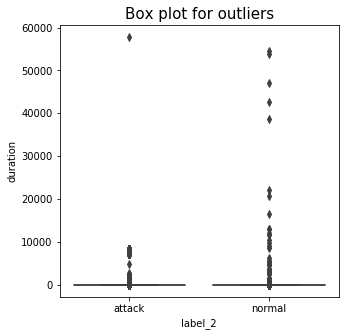

In [12]:
plt.figure(figsize=(5,5))
sns.boxplot(y='duration',x='label_2', data=kdd_test)
plt.title("Box plot for outliers", fontsize=15)
plt.show()


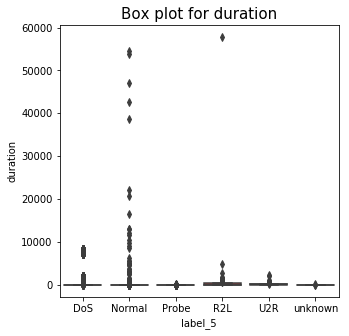

In [13]:
plt.figure(figsize=(5,5))
sns.boxplot(y='duration',x='label_5', data=kdd_test)
plt.title("Box plot for duration", fontsize=15)
plt.show()

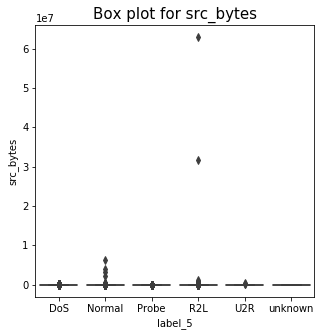

In [14]:
plt.figure(figsize=(5,5))
sns.boxplot(y='src_bytes',x='label_5', data=kdd_test)
plt.title("Box plot for src_bytes", fontsize=15)
plt.show()


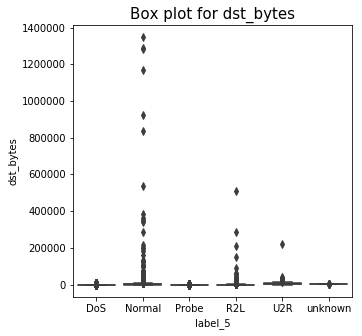

In [15]:
plt.figure(figsize=(5,5))
sns.boxplot(y='dst_bytes',x='label_5', data=kdd_test)
plt.title("Box plot for dst_bytes", fontsize=15)
plt.show()


Text(0.5,1,'Box plot for num_compromised')

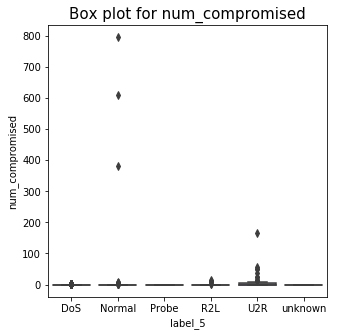

In [16]:
plt.figure(figsize=(5,5))
#plt.subplot(1,2,1)
sns.boxplot(y='num_compromised',x='label_5', data=kdd_test)
plt.title("Box plot for num_compromised", fontsize=15)

Text(0.5,1,'Box plot for num_root')

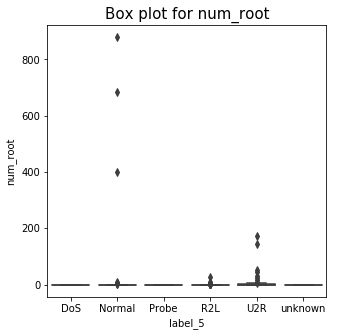

In [17]:
plt.figure(figsize=(5,5))
sns.boxplot(y='num_root',x='label_5', data=kdd_test)
plt.title("Box plot for num_root", fontsize=15)

In [18]:
y=kdd_test[kdd_test['duration'] > kdd_test['duration'].quantile(0.99)]
y['label_5'].value_counts()

DoS       209
Normal     16
R2L         1
Name: label_5, dtype: int64

In [19]:
y=kdd_test[kdd_test['src_bytes'] > kdd_test['src_bytes'].quantile(0.99)]
y['label_5'].value_counts()

Normal    8
R2L       3
Name: label_5, dtype: int64

In [20]:
y=kdd_test[kdd_test['dst_bytes'] > kdd_test['dst_bytes'].quantile(0.99)]
y['label_5'].value_counts()

Normal    207
R2L        10
U2R         9
Name: label_5, dtype: int64

In [21]:
y=kdd_test[kdd_test['num_compromised'] > kdd_test['num_compromised'].quantile(0.99)]
y['label_5'].value_counts()

U2R       24
Normal    16
R2L        4
Name: label_5, dtype: int64

In [22]:
y=kdd_test[kdd_test['num_root'] > kdd_test['num_root'].quantile(0.99)]
y['label_5'].value_counts()

U2R       23
R2L       18
Normal     7
Name: label_5, dtype: int64

There are significant amount of data above 0.99 quantile.Hence cannot be considered as outlier

In [13]:
kdd_test[content_attr].describe(percentiles = [0.25,0.50,0.75,0.85,0.90,0.95,0.99,1]).transpose()

,count,mean,std,min,25%,50%,75%,85%,90%,95%,99%,100%,max
hot,22544.0,0.105394,0.928428,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,101.0,101.0
num_failed_logins,22544.0,0.021647,0.150328,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,4.0
logged_in,22544.0,0.442202,0.496659,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
num_compromised,22544.0,0.119899,7.269597,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,796.0,796.0
root_shell,22544.0,0.002440,0.049334,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
su_attempted,22544.0,0.000266,0.021060,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
num_root,22544.0,0.114665,8.041614,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,878.0,878.0
num_file_creations,22544.0,0.008738,0.676842,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,100.0
num_shells,22544.0,0.001153,0.048014,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,5.0
num_access_files,22544.0,0.003549,0.067829,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,4.0


Text(0.5,1,'Box plot for outliers')

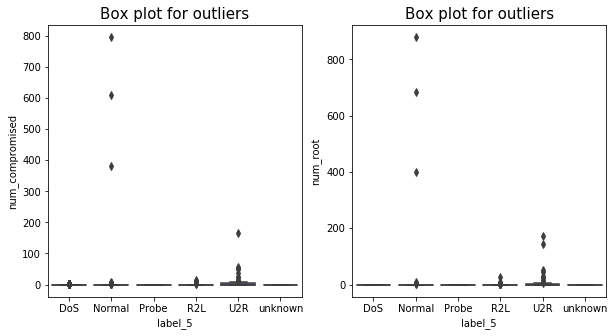

In [14]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.boxplot(y='num_compromised',x='label_5', data=kdd_test)
plt.title("Box plot for outliers", fontsize=15)
plt.subplot(1,2,2)
sns.boxplot(y='num_root',x='label_5', data=kdd_test)
plt.title("Box plot for outliers", fontsize=15)



In [15]:
print(len(detect_outlier(kdd_test['num_compromised'])))

20


In [16]:
kdd_test[kdd_test['num_compromised'] > kdd_test['num_compromised'].quantile(0.99)].shape

(44, 45)

In [17]:
print(len(detect_outlier(kdd_test['num_root'])))

12


In [18]:
kdd_test[kdd_test['num_root'] > kdd_test['num_compromised'].quantile(0.99)].shape

(34, 45)

#### There are significant amount of data above 0.99 quantile.Hence cannot be considered as outlier

In [19]:
kdd_test[time_attr].describe(percentiles = [0.25,0.50,0.75,0.85,0.90,0.95,0.99,1]).transpose()

,count,mean,std,min,25%,50%,75%,85%,90%,95%,99%,100%,max
count,22544.0,79.028345,128.539248,0.0,1.00,8.0,123.2500,219.00,256.00,400.85,511.0,511.0,511.0
srv_count,22544.0,31.124379,89.062532,0.0,1.00,6.0,16.0000,24.00,43.00,185.00,511.0,511.0,511.0
serror_rate,22544.0,0.102924,0.295367,0.0,0.00,0.0,0.0000,0.00,0.50,1.00,1.0,1.0,1.0
srv_serror_rate,22544.0,0.103635,0.298332,0.0,0.00,0.0,0.0000,0.00,0.60,1.00,1.0,1.0,1.0
rerror_rate,22544.0,0.238463,0.416118,0.0,0.00,0.0,0.2500,1.00,1.00,1.00,1.0,1.0,1.0
srv_rerror_rate,22544.0,0.235179,0.416215,0.0,0.00,0.0,0.0725,1.00,1.00,1.00,1.0,1.0,1.0
same_srv_rate,22544.0,0.740345,0.412496,0.0,0.25,1.0,1.0000,1.00,1.00,1.00,1.0,1.0,1.0
diff_srv_rate,22544.0,0.094074,0.259138,0.0,0.00,0.0,0.0600,0.07,0.09,1.00,1.0,1.0,1.0
srv_diff_host_rate,22544.0,0.098110,0.253545,0.0,0.00,0.0,0.0000,0.16,0.33,1.00,1.0,1.0,1.0


In [20]:
kdd_test[host_attr].describe(percentiles = [0.25,0.50,0.75,0.85,0.90,0.95,0.99,1]).transpose()

,count,mean,std,min,25%,50%,75%,85%,90%,95%,99%,100%,max
dst_host_count,22544.0,193.869411,94.035663,0.0,121.00,255.00,255.00,255.00,255.00,255.00,255.0000,255.0,255.0
dst_host_srv_count,22544.0,140.750532,111.783972,0.0,15.00,168.00,255.00,255.00,255.00,255.00,255.0000,255.0,255.0
dst_host_same_srv_rate,22544.0,0.608722,0.435688,0.0,0.07,0.92,1.00,1.00,1.00,1.00,1.0000,1.0,1.0
dst_host_diff_srv_rate,22544.0,0.090540,0.220717,0.0,0.00,0.01,0.06,0.08,0.15,0.75,1.0000,1.0,1.0
dst_host_same_src_port_rate,22544.0,0.132261,0.306268,0.0,0.00,0.00,0.03,0.20,0.85,1.00,1.0000,1.0,1.0
dst_host_srv_diff_host_rate,22544.0,0.019638,0.085394,0.0,0.00,0.00,0.01,0.03,0.04,0.06,0.4057,1.0,1.0
dst_host_serror_rate,22544.0,0.097814,0.273139,0.0,0.00,0.00,0.00,0.05,0.35,1.00,1.0000,1.0,1.0
dst_host_srv_serror_rate,22544.0,0.099426,0.281866,0.0,0.00,0.00,0.00,0.01,0.46,1.00,1.0000,1.0,1.0
dst_host_rerror_rate,22544.0,0.233385,0.387229,0.0,0.00,0.00,0.36,0.94,1.00,1.00,1.0000,1.0,1.0
dst_host_srv_rerror_rate,22544.0,0.226683,0.400875,0.0,0.00,0.00,0.17,1.00,1.00,1.00,1.0000,1.0,1.0


## KDD TRAIN EDA

In [21]:
kdd_test.select_dtypes("object").columns

Index(['protocol_type', 'service', 'flag', 'attack', 'label_5', 'label_2'], dtype='object')

In [22]:
categ_columns=['protocol_type', 'service', 'flag']


In [23]:
kdd_test['protocol_type'].value_counts()


tcp     18880
udp      2621
icmp     1043
Name: protocol_type, dtype: int64

In [24]:
kdd_test['service'].value_counts().head()

http       7853
private    4774
telnet     1626
pop_3      1019
smtp        934
Name: service, dtype: int64

In [25]:
kdd_test['flag'].value_counts()

SF        14875
REJ        3850
S0         2013
RSTO        773
RSTR        669
S3          249
SH           73
S1           21
S2           15
OTH           4
RSTOS0        2
Name: flag, dtype: int64

In [26]:
kdd_test.select_dtypes([np.number]).columns

Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
       'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'last_flag'],
      dtype='object')

In [29]:
len(kdd_test.select_dtypes([np.number]).columns)

39

In [30]:
binary_cols=['land','logged_in','root_shell', 'su_attempted','is_host_login','is_guest_login']


### BASIC ATTRIBUTES

    duration 
    protocol_type
    service
    flag
    src_bytes
    dst_bytes
    land
    wrong_fragment
    urgent


In [31]:
kdd_test[basic_attr].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
duration,22544.0,218.859076,1407.176612,0.0,0.0,0.0,0.0,57715.0
src_bytes,22544.0,10395.450231,472786.431088,0.0,0.0,54.0,287.0,62825648.0
dst_bytes,22544.0,2056.018808,21219.297609,0.0,0.0,46.0,601.0,1345927.0
land,22544.0,0.000311,0.017619,0.0,0.0,0.0,0.0,1.0
wrong_fragment,22544.0,0.008428,0.142599,0.0,0.0,0.0,0.0,3.0
urgent,22544.0,0.000710,0.036473,0.0,0.0,0.0,0.0,3.0


In [32]:
print(pd.crosstab(kdd_test['protocol_type'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['protocol_type'], kdd_test['label_5']))

label_2        attack  normal
protocol_type                
icmp              950      93
tcp             11038    7842
udp               845    1776 

label_5         DoS  Normal  Probe   R2L  U2R  unknown
protocol_type                                         
icmp            706      93    240     4    0        0
tcp            6447    7842   1864  2367   67      293
udp              14    1776    317   514    0        0


In [33]:
print(pd.crosstab(kdd_test['flag'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['flag'], kdd_test['label_5']))

label_2  attack  normal
flag                   
OTH           4       0
REJ        3816      34
RSTO        771       2
RSTOS0        1       1
RSTR        625      44
S0         2013       0
S1           10      11
S2            7       8
S3          245       4
SF         5268    9607
SH           73       0 

label_5   DoS  Normal  Probe   R2L  U2R  unknown
flag                                            
OTH         0       0      4     0    0        0
REJ      2761      34    943   112    0        0
RSTO      374       2    369    28    0        0
RSTOS0      0       1      1     0    0        0
RSTR      534      44     87     4    0        0
S0       1775       0    238     0    0        0
S1          1      11      4     5    0        0
S2          6       8      1     0    0        0
S3        241       4      0     4    0        0
SF       1475    9607    701  2732   67      293
SH          0       0     73     0    0        0


In [34]:
print(pd.crosstab(kdd_test['land'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['land'], kdd_test['label_5']))


label_2  attack  normal
land                   
0         12826    9711
1             7       0 

label_5   DoS  Normal  Probe   R2L  U2R  unknown
land                                            
0        7160    9711   2421  2885   67      293
1           7       0      0     0    0        0


In [35]:
print(pd.crosstab(kdd_test['wrong_fragment'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['wrong_fragment'], kdd_test['label_5']))

label_2         attack  normal
wrong_fragment                
0                12785    9659
1                   40      15
3                    8      37 

label_5          DoS  Normal  Probe   R2L  U2R  unknown
wrong_fragment                                         
0               7119    9659   2421  2885   67      293
1                 40      15      0     0    0        0
3                  8      37      0     0    0        0


In [36]:
print(pd.crosstab(kdd_test['urgent'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['urgent'], kdd_test['label_5']))

label_2  attack  normal
urgent                 
0         12823    9711
1             5       0
2             4       0
3             1       0 

label_5   DoS  Normal  Probe   R2L  U2R  unknown
urgent                                          
0        7167    9711   2421  2884   58      293
1           0       0      0     1    4        0
2           0       0      0     0    4        0
3           0       0      0     0    1        0


In [37]:
print(pd.crosstab(kdd_test['last_flag'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['last_flag'], kdd_test['label_5']))

label_2    attack  normal
last_flag                
0             116       7
1              76      11
2              48       7
3              61      55
4              67      34
5              73      30
6             122      35
7             224      25
8             120      11
9              94      12
10            170      25
11            443      18
12            465      21
13            484      35
14            692      44
15           1131      45
16            632      49
17            723     445
18           2213     754
19            790     100
20            954     389
21           3135    7559 

label_5     DoS  Normal  Probe  R2L  U2R  unknown
last_flag                                        
0             2       7      5   95   14        0
1             2      11      2   54   18        0
2             2       7      0   45    1        0
3             0      55      2   53    6        0
4             1      34      4   57    5        0
5             1      30 

In [38]:
categ_basic=['protocol_type','service','flag','wrong_fragment','urgent','last_flag']

<Figure size 864x864 with 0 Axes>

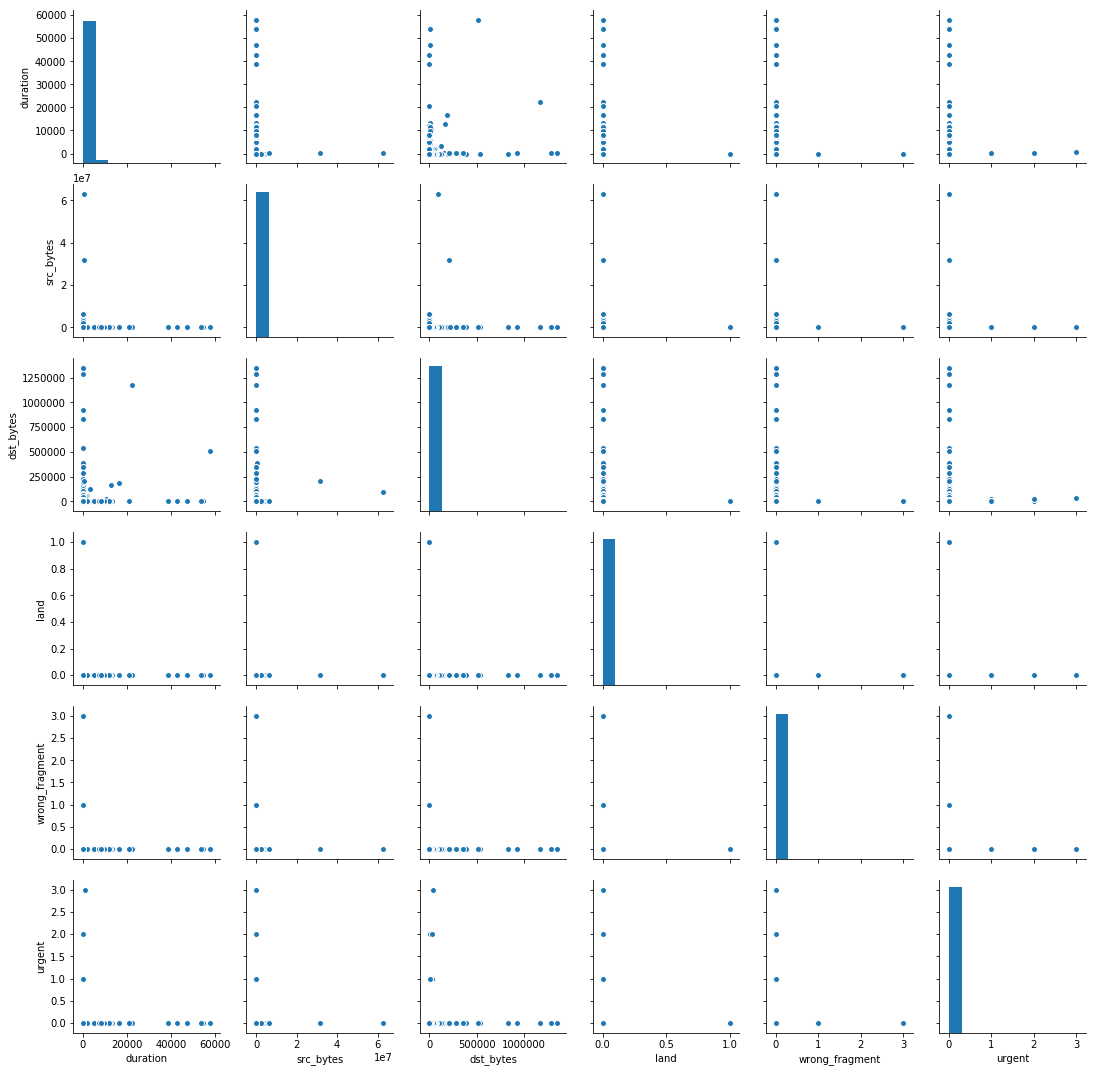

In [39]:

plt.figure(figsize = (12, 12))
sns.pairplot(kdd_test[basic_attr])
plt.show()


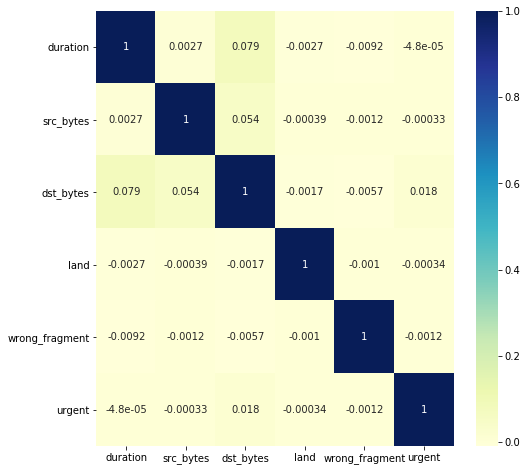

In [40]:
plt.figure(figsize = (8, 8))
sns.heatmap(kdd_test[basic_attr].corr(), annot = True, cmap="YlGnBu")
plt.show()


#### protocol_type,flag,land vs attack

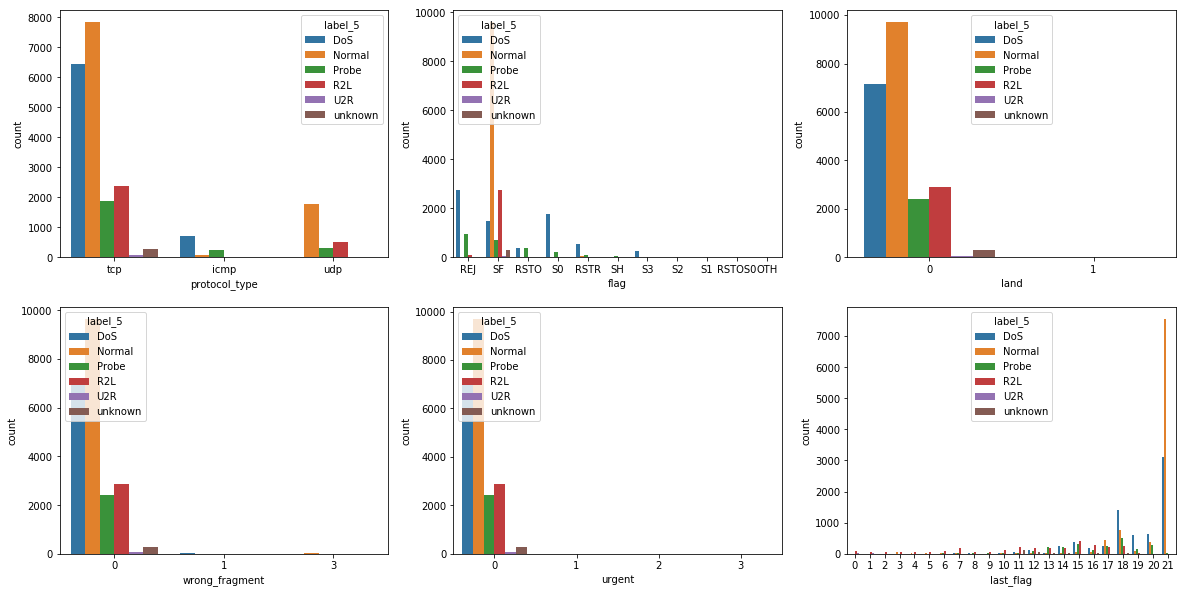

In [41]:
plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
sns.countplot(x='protocol_type',data=kdd_test,hue='label_5')
plt.subplot(2,3,2)
sns.countplot(x='flag',data=kdd_test,hue='label_5')
plt.subplot(2,3,3)
sns.countplot(x='land',data=kdd_test,hue='label_5')
plt.subplot(2,3,4)
sns.countplot(x='wrong_fragment',data=kdd_test,hue='label_5')
plt.subplot(2,3,5)
sns.countplot(x='urgent',data=kdd_test,hue='label_5')
plt.subplot(2,3,6)
sns.countplot(x='last_flag',data=kdd_test,hue='label_5')


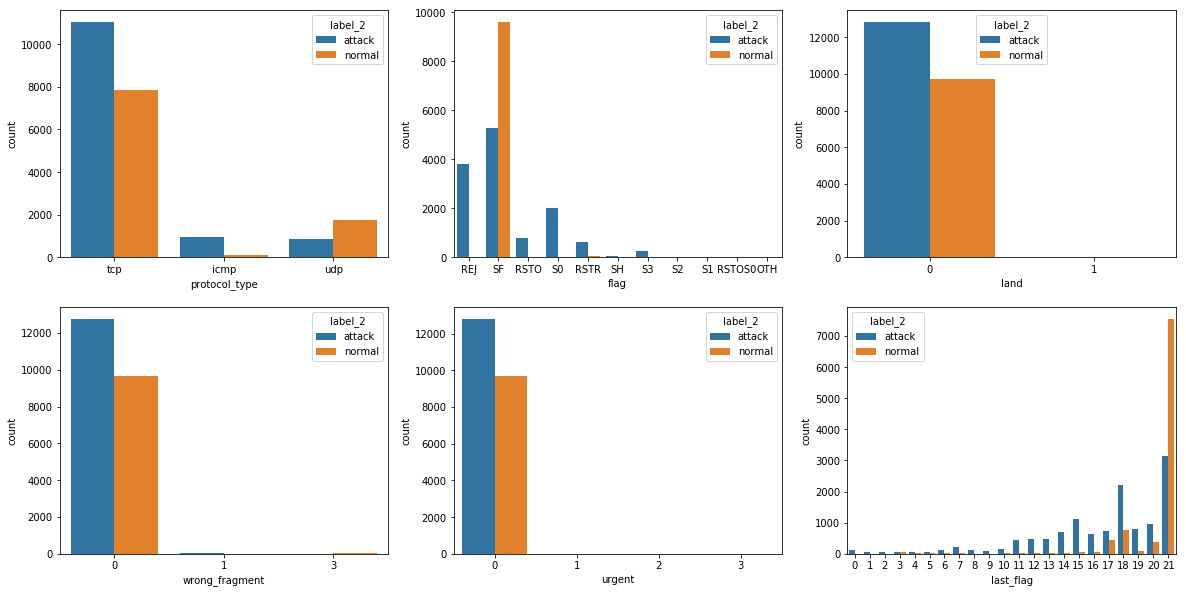

In [42]:
plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
sns.countplot(x='protocol_type',data=kdd_test,hue='label_2')
plt.subplot(2,3,2)
sns.countplot(x='flag',data=kdd_test,hue='label_2')
plt.subplot(2,3,3)
sns.countplot(x='land',data=kdd_test,hue='label_2')
plt.subplot(2,3,4)
sns.countplot(x='wrong_fragment',data=kdd_test,hue='label_2')
plt.subplot(2,3,5)
sns.countplot(x='urgent',data=kdd_test,hue='label_2')
plt.subplot(2,3,6)
sns.countplot(x='last_flag',data=kdd_test,hue='label_2')

#### Basic attributes vz attacks

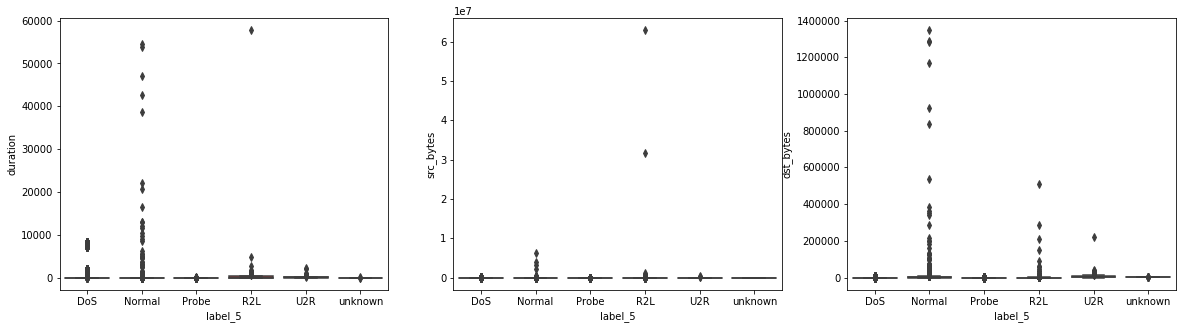

In [43]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
sns.boxplot(y='duration',data=kdd_test,x='label_5')
plt.subplot(1,3,2)
sns.boxplot(y='src_bytes',data=kdd_test,x='label_5')
plt.subplot(1,3,3)
sns.boxplot(y='dst_bytes',data=kdd_test,x='label_5')


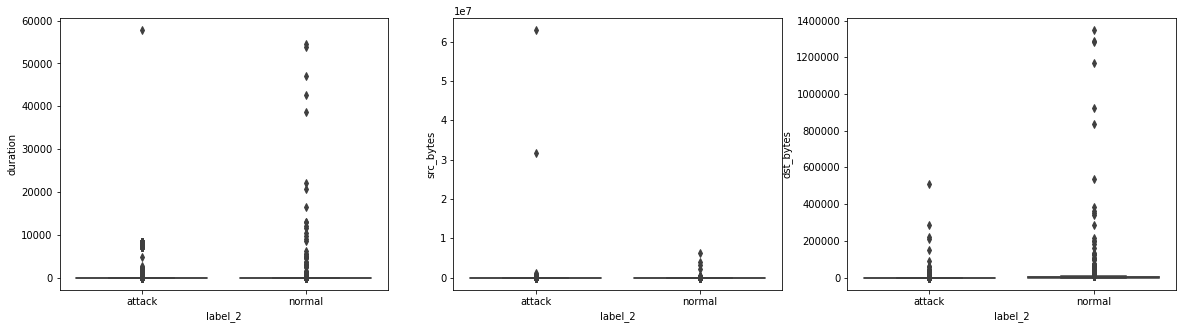

In [44]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
sns.boxplot(y='duration',data=kdd_test,x='label_2')
plt.subplot(1,3,2)
sns.boxplot(y='src_bytes',data=kdd_test,x='label_2')
plt.subplot(1,3,3)
sns.boxplot(y='dst_bytes',data=kdd_test,x='label_2')


### CONTENT RELATED ATTRIBUTES

    hot
    num_failed_logins
    logged_in
    num_compromised
    root_shell
    su_attempted
    num_root
    num_file_creations
    num_shells
    num_access_files
    num_outbound_cmds
    is_host_login
    is_guest_login



<Figure size 864x864 with 0 Axes>

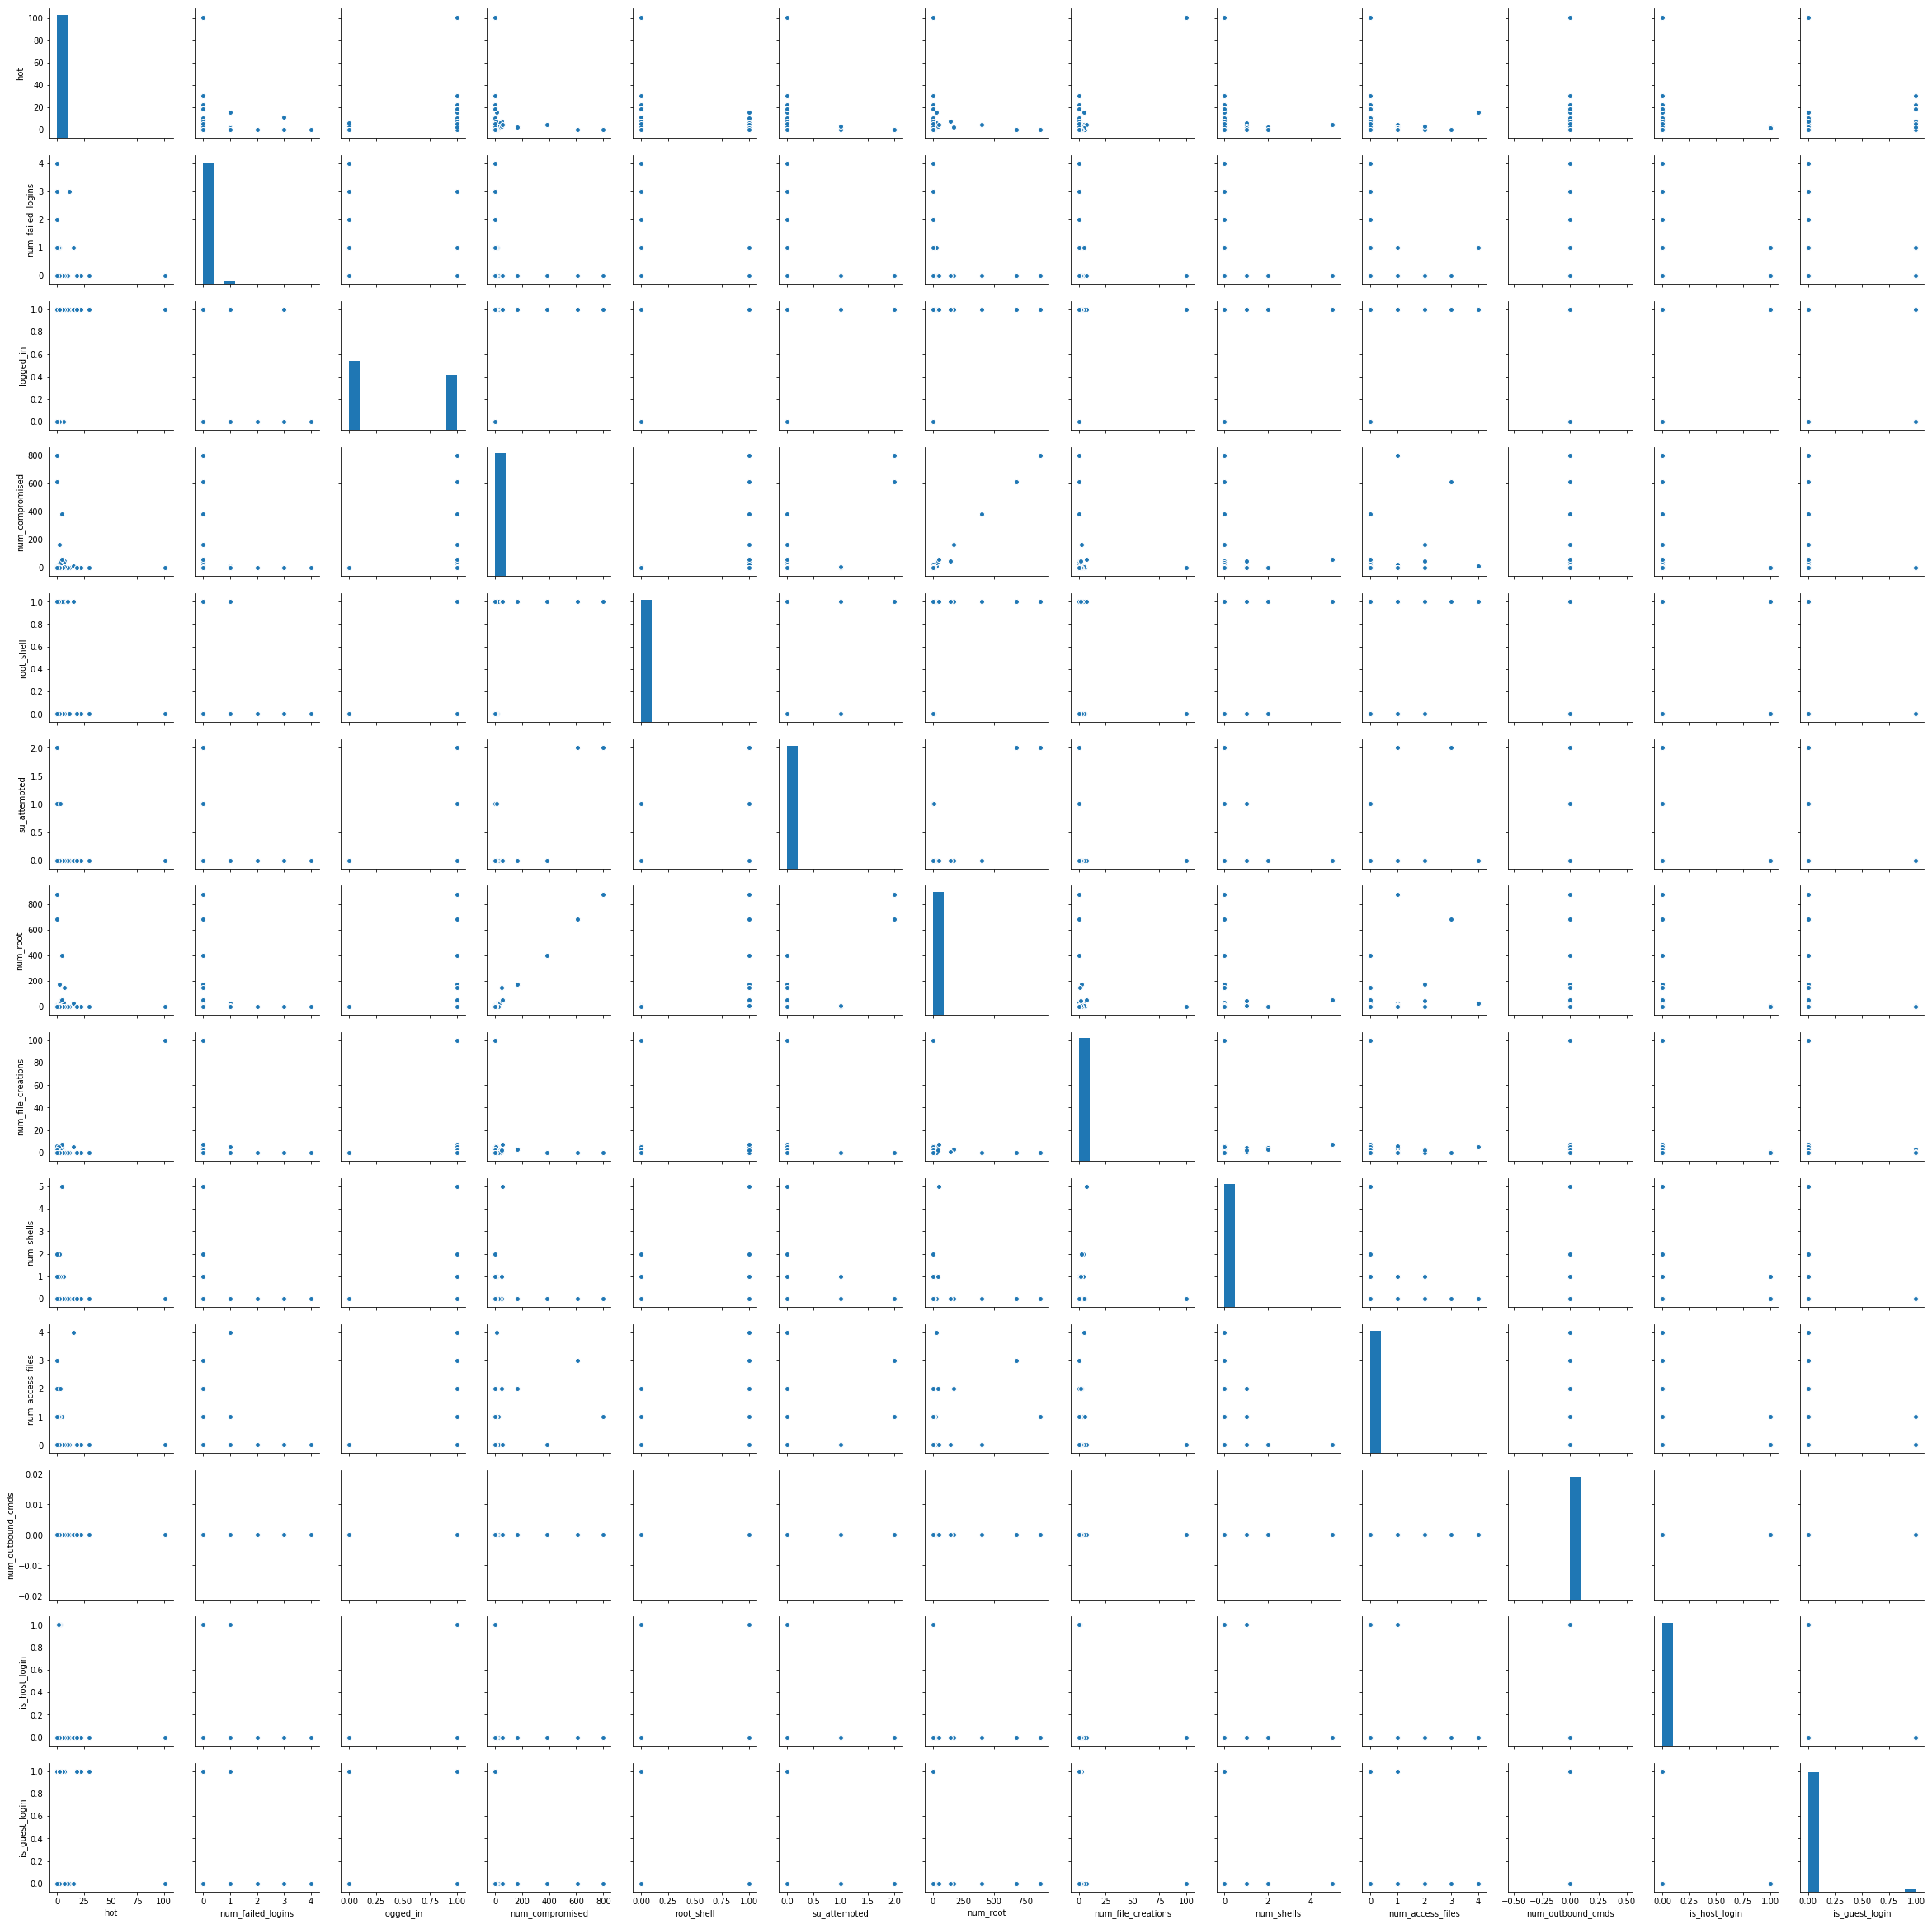

In [45]:
plt.figure(figsize = (12, 12))
sns.pairplot(kdd_test[content_attr])
plt.show()

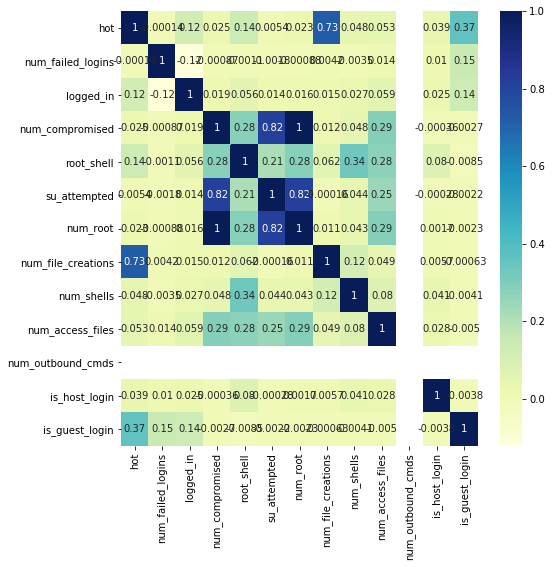

In [46]:
plt.figure(figsize = (8, 8))
sns.heatmap(kdd_test[content_attr].corr(), annot = True, cmap="YlGnBu")
plt.show()


In [47]:
kdd_test[content_attr].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
hot,22544.0,0.105394,0.928428,0.0,0.0,0.0,0.0,101.0
num_failed_logins,22544.0,0.021647,0.150328,0.0,0.0,0.0,0.0,4.0
logged_in,22544.0,0.442202,0.496659,0.0,0.0,0.0,1.0,1.0
num_compromised,22544.0,0.119899,7.269597,0.0,0.0,0.0,0.0,796.0
root_shell,22544.0,0.002440,0.049334,0.0,0.0,0.0,0.0,1.0
su_attempted,22544.0,0.000266,0.021060,0.0,0.0,0.0,0.0,2.0
num_root,22544.0,0.114665,8.041614,0.0,0.0,0.0,0.0,878.0
num_file_creations,22544.0,0.008738,0.676842,0.0,0.0,0.0,0.0,100.0
num_shells,22544.0,0.001153,0.048014,0.0,0.0,0.0,0.0,5.0
num_access_files,22544.0,0.003549,0.067829,0.0,0.0,0.0,0.0,4.0


In [48]:
print(pd.crosstab(kdd_test['hot'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['hot'], kdd_test['label_5']))


label_2  attack  normal
hot                    
0         11894    9643
1            76      14
2           841       5
3             8       4
4             3      17
5             2       9
6             4       2
7             2       7
10            2       0
11            0       1
15            1       0
18            0       3
19            0       1
22            0       2
30            0       2
101           0       1 

label_5   DoS  Normal  Probe   R2L  U2R  unknown
hot                                             
0        6814    9643   2421  2343   23      293
1          38      14      0    22   16        0
2         314       5      0   517   10        0
3           1       4      0     2    5        0
4           0      17      0     0    3        0
5           0       9      0     0    2        0
6           0       2      0     0    4        0
7           0       7      0     0    2        0
10          0       0      0     0    2        0
11          0       1      

In [49]:
print(pd.crosstab(kdd_test['num_failed_logins'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['num_failed_logins'], kdd_test['label_5']))


label_2            attack  normal
num_failed_logins                
0                   12360    9706
1                     471       2
2                       1       0
3                       0       3
4                       1       0 

label_5             DoS  Normal  Probe   R2L  U2R  unknown
num_failed_logins                                         
0                  7167    9706   2421  2415   64      293
1                     0       2      0   468    3        0
2                     0       0      0     1    0        0
3                     0       3      0     0    0        0
4                     0       0      0     1    0        0


In [50]:
print(pd.crosstab(kdd_test['logged_in'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['logged_in'], kdd_test['label_5']))


label_2    attack  normal
logged_in                
0           10214    2361
1            2619    7350 

label_5     DoS  Normal  Probe   R2L  U2R  unknown
logged_in                                         
0          6315    2361   2286  1598   15        0
1           852    7350    135  1287   52      293


In [51]:
print(pd.crosstab(kdd_test['root_shell'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['root_shell'], kdd_test['label_5']))


label_2     attack  normal
root_shell                
0            12796    9693
1               37      18 

label_5      DoS  Normal  Probe   R2L  U2R  unknown
root_shell                                         
0           7167    9693   2421  2876   39      293
1              0      18      0     9   28        0


In [52]:
print(pd.crosstab(kdd_test['su_attempted'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['su_attempted'], kdd_test['label_5']))


label_2       attack  normal
su_attempted                
0              12832    9708
1                  1       1
2                  0       2 

label_5        DoS  Normal  Probe   R2L  U2R  unknown
su_attempted                                         
0             7167    9708   2421  2884   67      293
1                0       1      0     1    0        0
2                0       2      0     0    0        0


In [53]:
print(pd.crosstab(kdd_test['su_attempted'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['su_attempted'], kdd_test['label_5']))


label_2       attack  normal
su_attempted                
0              12832    9708
1                  1       1
2                  0       2 

label_5        DoS  Normal  Probe   R2L  U2R  unknown
su_attempted                                         
0             7167    9708   2421  2884   67      293
1                0       1      0     1    0        0
2                0       2      0     0    0        0


In [54]:
print(pd.crosstab(kdd_test['num_file_creations'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['num_file_creations'], kdd_test['label_5']))


label_2             attack  normal
num_file_creations                
0                    12797    9705
1                       13       4
2                        8       1
3                        5       0
4                        6       0
5                        2       0
6                        1       0
7                        1       0
100                      0       1 

label_5              DoS  Normal  Probe   R2L  U2R  unknown
num_file_creations                                         
0                   7167    9705   2421  2879   37      293
1                      0       4      0     3   10        0
2                      0       1      0     0    8        0
3                      0       0      0     2    3        0
4                      0       0      0     0    6        0
5                      0       0      0     1    1        0
6                      0       0      0     0    1        0
7                      0       0      0     0    1        0
100          

In [55]:
print(pd.crosstab(kdd_test['num_file_creations'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['num_file_creations'], kdd_test['label_5']))


label_2             attack  normal
num_file_creations                
0                    12797    9705
1                       13       4
2                        8       1
3                        5       0
4                        6       0
5                        2       0
6                        1       0
7                        1       0
100                      0       1 

label_5              DoS  Normal  Probe   R2L  U2R  unknown
num_file_creations                                         
0                   7167    9705   2421  2879   37      293
1                      0       4      0     3   10        0
2                      0       1      0     0    8        0
3                      0       0      0     2    3        0
4                      0       0      0     0    6        0
5                      0       0      0     1    1        0
6                      0       0      0     0    1        0
7                      0       0      0     0    1        0
100          

In [56]:
print(pd.crosstab(kdd_test['num_shells'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['num_shells'], kdd_test['label_5']))


label_2     attack  normal
num_shells                
0            12814    9711
1               15       0
2                3       0
5                1       0 

label_5      DoS  Normal  Probe   R2L  U2R  unknown
num_shells                                         
0           7167    9711   2421  2882   51      293
1              0       0      0     2   13        0
2              0       0      0     1    2        0
5              0       0      0     0    1        0


In [57]:
print(pd.crosstab(kdd_test['num_access_files'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['num_access_files'], kdd_test['label_5']))


label_2           attack  normal
num_access_files                
0                  12813    9659
1                     17      50
2                      2       1
3                      0       1
4                      1       0 

label_5            DoS  Normal  Probe   R2L  U2R  unknown
num_access_files                                         
0                 7167    9659   2421  2874   58      293
1                    0      50      0    10    7        0
2                    0       1      0     0    2        0
3                    0       1      0     0    0        0
4                    0       0      0     1    0        0


In [58]:
print(pd.crosstab(kdd_test['num_outbound_cmds'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['num_outbound_cmds'], kdd_test['label_5']))


label_2            attack  normal
num_outbound_cmds                
0                   12833    9711 

label_5             DoS  Normal  Probe   R2L  U2R  unknown
num_outbound_cmds                                         
0                  7167    9711   2421  2885   67      293


In [59]:
print(pd.crosstab(kdd_test['is_host_login'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['is_host_login'], kdd_test['label_5']))

label_2        attack  normal
is_host_login                
0               12822    9711
1                  11       0 

label_5         DoS  Normal  Probe   R2L  U2R  unknown
is_host_login                                         
0              7167    9711   2421  2878   63      293
1                 0       0      0     7    4        0


In [60]:
print(pd.crosstab(kdd_test['is_guest_login'], kdd_test['label_2']),"\n")
print(pd.crosstab(kdd_test['is_guest_login'], kdd_test['label_5']))

label_2         attack  normal
is_guest_login                
0                12236    9667
1                  597      44 

label_5          DoS  Normal  Probe   R2L  U2R  unknown
is_guest_login                                         
0               7167    9667   2421  2288   67      293
1                  0      44      0   597    0        0


### No variance in data for num_outbound_cmds and is_host_login . Hence can be dropped

In [61]:
categ_content=['hot','num_failed_logins','num_file_creations','num_shells','num_access_files']

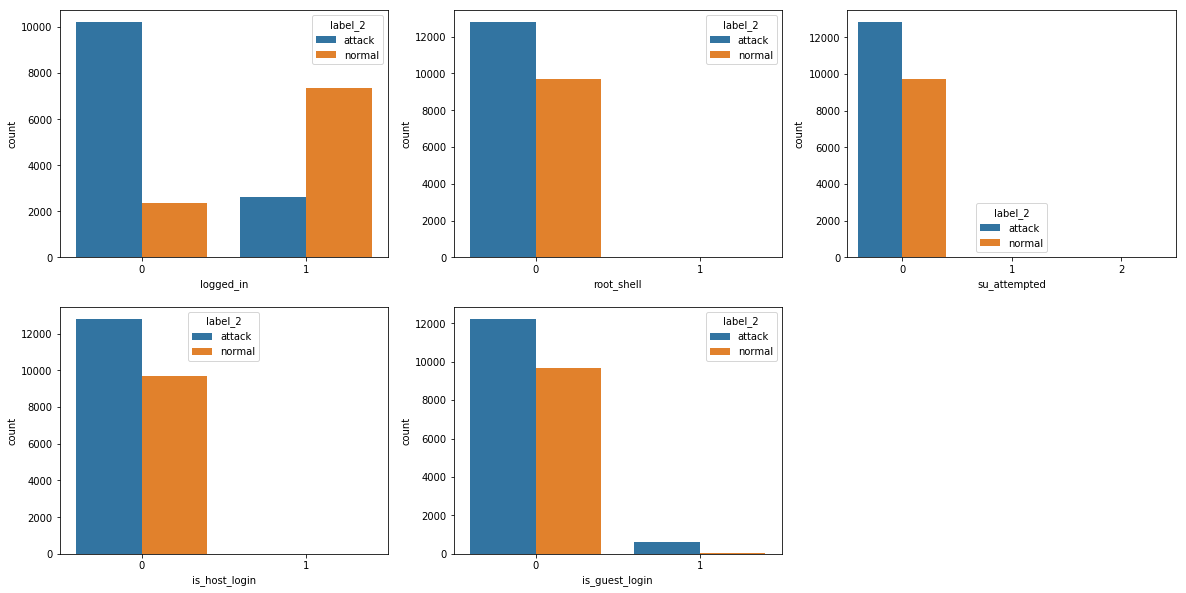

In [62]:
plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
sns.countplot(x='logged_in',data=kdd_test,hue='label_2')
plt.subplot(2,3,2)
sns.countplot(x='root_shell',data=kdd_test,hue='label_2')
plt.subplot(2,3,3)
sns.countplot(x='su_attempted',data=kdd_test,hue='label_2')
plt.subplot(2,3,4)
sns.countplot(x='is_host_login',data=kdd_test,hue='label_2')
plt.subplot(2,3,5)
sns.countplot(x='is_guest_login',data=kdd_test,hue='label_2')


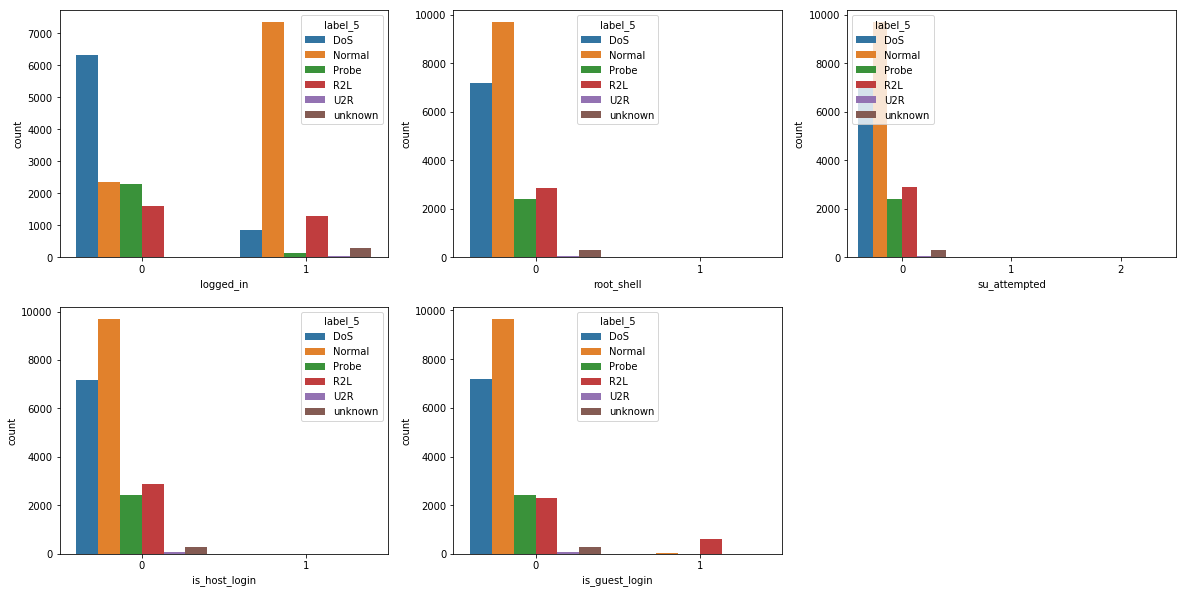

In [27]:
plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
sns.countplot(x='logged_in',data=kdd_test,hue='label_5')
plt.subplot(2,3,2)
sns.countplot(x='root_shell',data=kdd_test,hue='label_5')
plt.subplot(2,3,3)
sns.countplot(x='su_attempted',data=kdd_test,hue='label_5')
plt.subplot(2,3,4)
sns.countplot(x='is_host_login',data=kdd_test,hue='label_5')
plt.subplot(2,3,5)
sns.countplot(x='is_guest_login',data=kdd_test,hue='label_5')


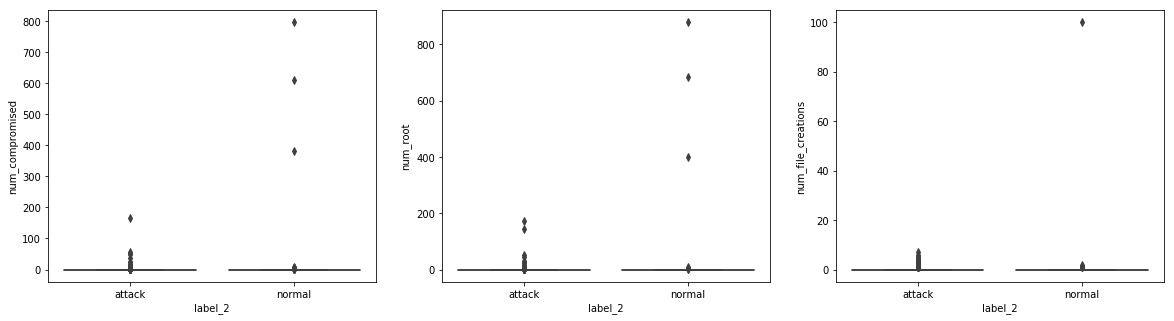

In [63]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
sns.boxplot(y='num_compromised',data=kdd_test,x='label_2')
plt.subplot(1,3,2)
sns.boxplot(y='num_root',data=kdd_test,x='label_2')
plt.subplot(1,3,3)
sns.boxplot(y='num_file_creations',data=kdd_test,x='label_2')


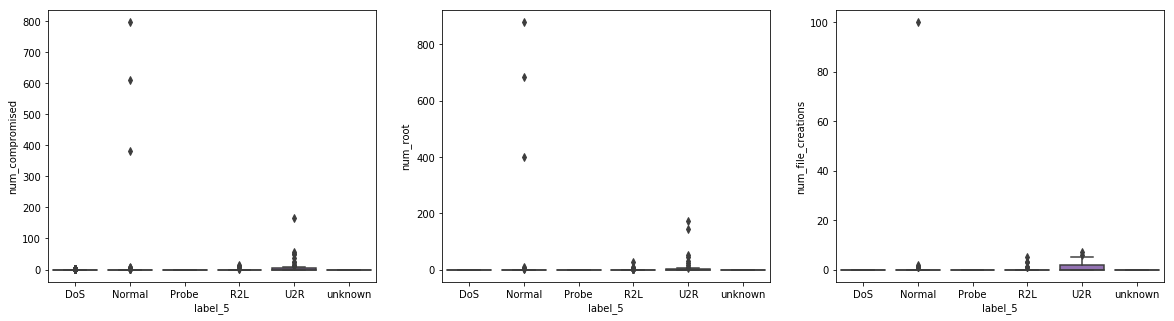

In [64]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
sns.boxplot(y='num_compromised',data=kdd_test,x='label_5')
plt.subplot(1,3,2)
sns.boxplot(y='num_root',data=kdd_test,x='label_5')
plt.subplot(1,3,3)
sns.boxplot(y='num_file_creations',data=kdd_test,x='label_5')


### TIME RELATED ATTRIBUTES
count
srv_count
serror_rate
srv_serror_rate
rerror_rate
srv_rerror_rate
same_srv_rate
diff_srv_rate
srv_diff_host_rate


In [65]:
kdd_test[time_attr].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
count,22544.0,79.028345,128.539248,0.0,1.00,8.0,123.2500,511.0
srv_count,22544.0,31.124379,89.062532,0.0,1.00,6.0,16.0000,511.0
serror_rate,22544.0,0.102924,0.295367,0.0,0.00,0.0,0.0000,1.0
srv_serror_rate,22544.0,0.103635,0.298332,0.0,0.00,0.0,0.0000,1.0
rerror_rate,22544.0,0.238463,0.416118,0.0,0.00,0.0,0.2500,1.0
srv_rerror_rate,22544.0,0.235179,0.416215,0.0,0.00,0.0,0.0725,1.0
same_srv_rate,22544.0,0.740345,0.412496,0.0,0.25,1.0,1.0000,1.0
diff_srv_rate,22544.0,0.094074,0.259138,0.0,0.00,0.0,0.0600,1.0
srv_diff_host_rate,22544.0,0.098110,0.253545,0.0,0.00,0.0,0.0000,1.0


/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda

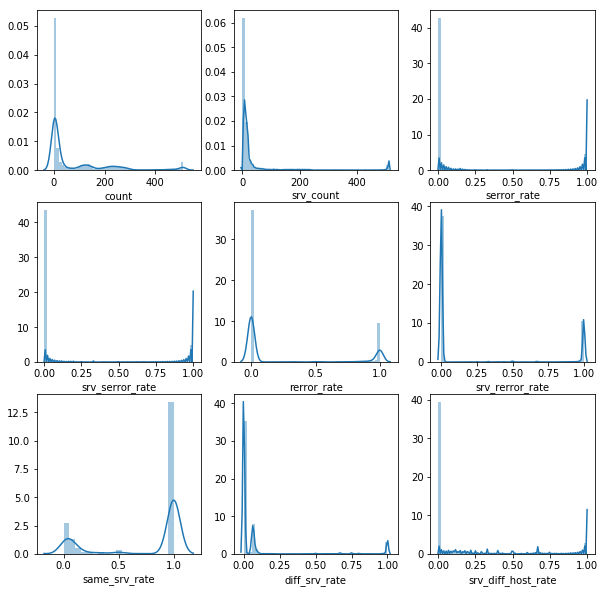

In [15]:
plt.figure(figsize=(10,10))

plt.subplot(3,3,1)
sns.distplot(kdd_test['count'])

plt.subplot(3,3,2)
sns.distplot(kdd_test['srv_count'])

plt.subplot(3,3,3)
sns.distplot(kdd_test['serror_rate'])

plt.subplot(3,3,4)
sns.distplot(kdd_test['srv_serror_rate'])


plt.subplot(3,3,5)
sns.distplot(kdd_test['rerror_rate'])

plt.subplot(3,3,6)
sns.distplot(kdd_test['srv_rerror_rate'])

plt.subplot(3,3,7)
sns.distplot(kdd_test['same_srv_rate'])

plt.subplot(3,3,8)
sns.distplot(kdd_test['diff_srv_rate'])

plt.subplot(3,3,9)
sns.distplot(kdd_test['srv_diff_host_rate'])

<Figure size 864x864 with 0 Axes>

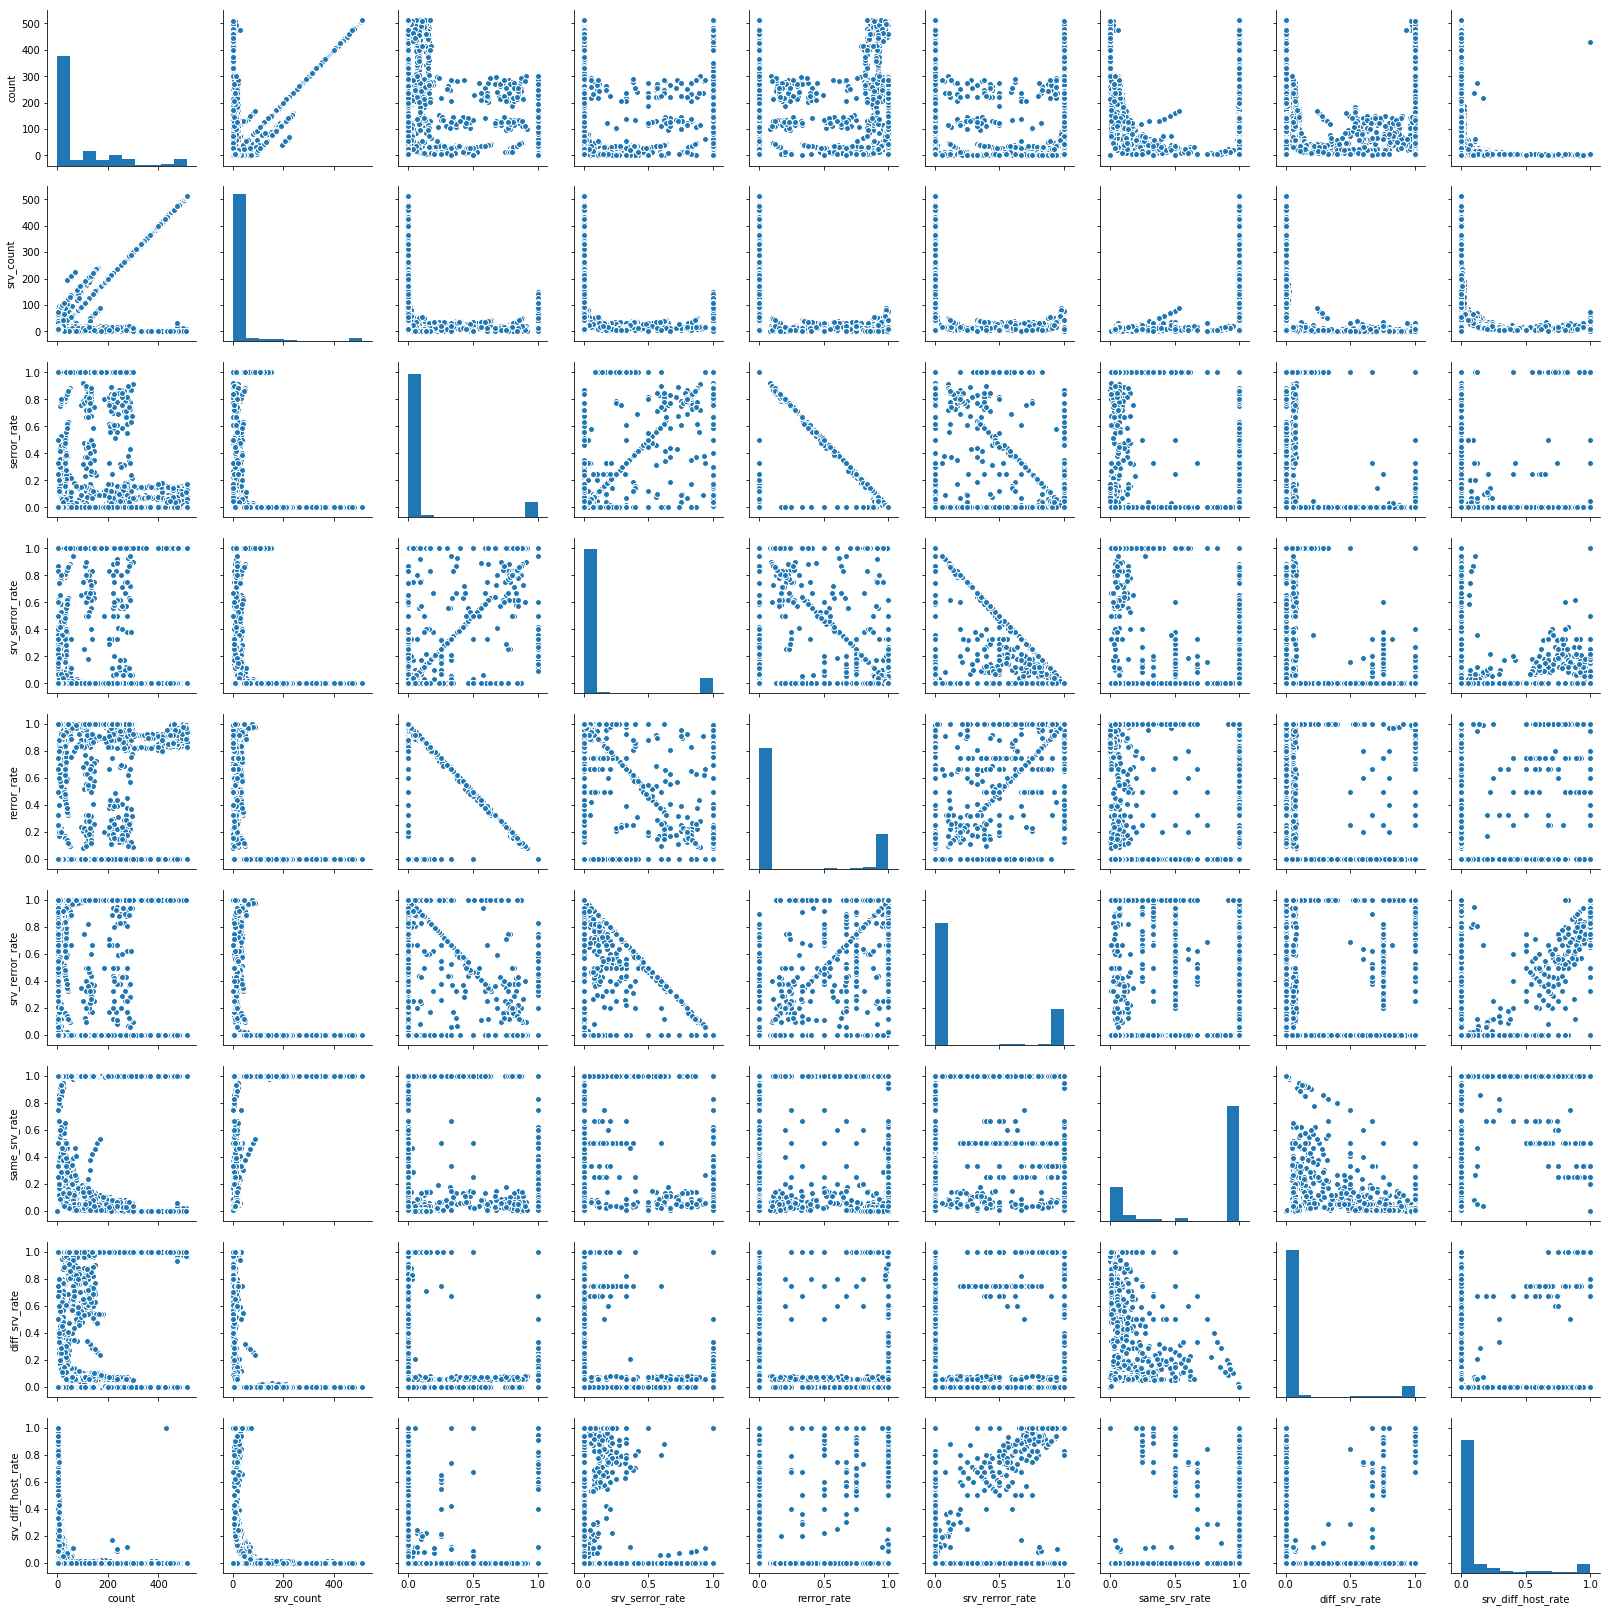

In [66]:
plt.figure(figsize = (12, 12))
sns.pairplot(kdd_test[time_attr])
plt.show()

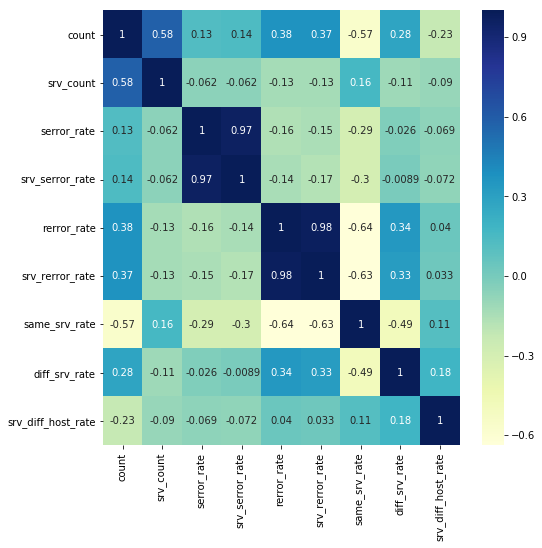

In [67]:
plt.figure(figsize = (8, 8))
sns.heatmap(kdd_test[time_attr].corr(), annot = True, cmap="YlGnBu")
plt.show()


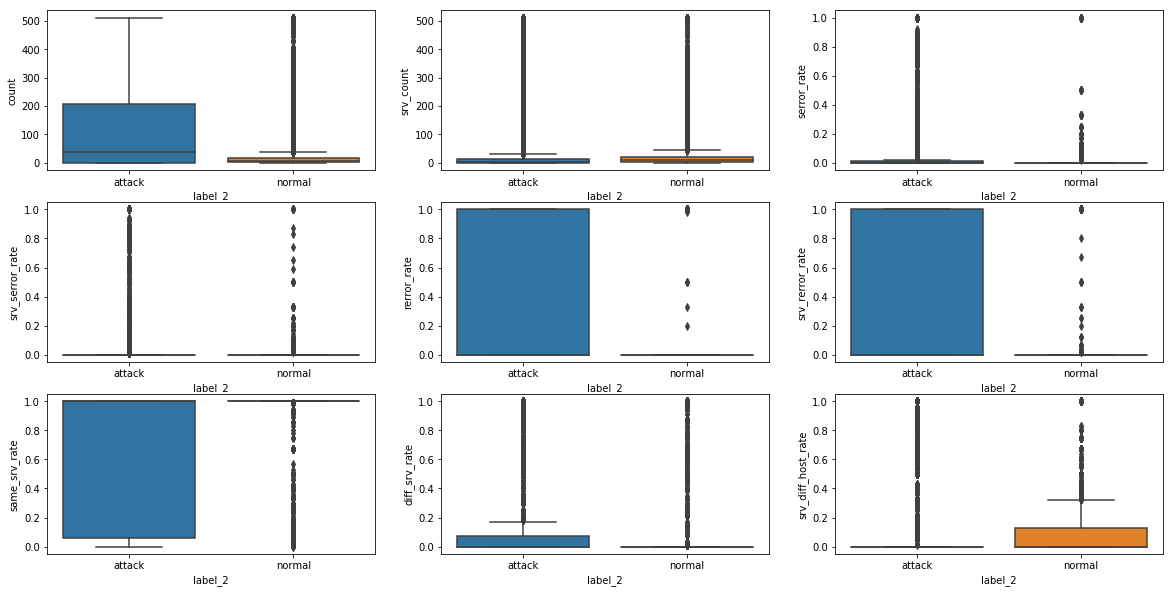

In [68]:
plt.figure(figsize=(20,10))
plt.subplot(3,3,1)
sns.boxplot(y='count',data=kdd_test,x='label_2')
plt.subplot(3,3,2)
sns.boxplot(y='srv_count',data=kdd_test,x='label_2')
plt.subplot(3,3,3)
sns.boxplot(y='serror_rate',data=kdd_test,x='label_2')
plt.subplot(3,3,4)
sns.boxplot(y='srv_serror_rate',data=kdd_test,x='label_2')
plt.subplot(3,3,5)
sns.boxplot(y='rerror_rate',data=kdd_test,x='label_2')
plt.subplot(3,3,6)
sns.boxplot(y='srv_rerror_rate',data=kdd_test,x='label_2')
plt.subplot(3,3,7)
sns.boxplot(y='same_srv_rate',data=kdd_test,x='label_2')
plt.subplot(3,3,8)
sns.boxplot(y='diff_srv_rate',data=kdd_test,x='label_2')
plt.subplot(3,3,9)
sns.boxplot(y='srv_diff_host_rate',data=kdd_test,x='label_2')


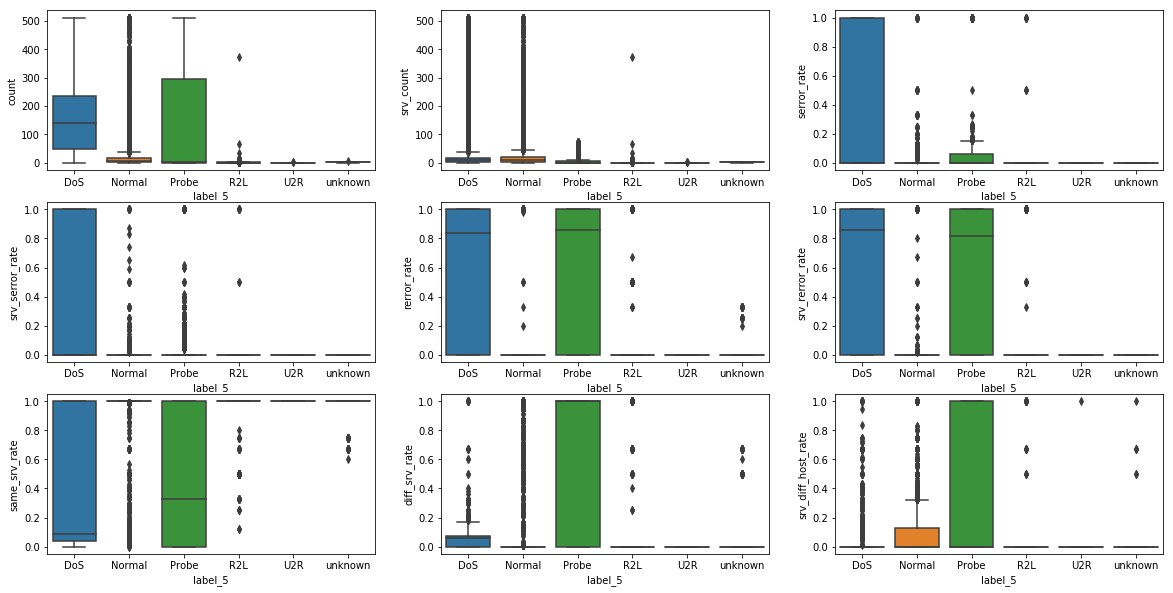

In [69]:
plt.figure(figsize=(20,10))
plt.subplot(3,3,1)
sns.boxplot(y='count',data=kdd_test,x='label_5')
plt.subplot(3,3,2)
sns.boxplot(y='srv_count',data=kdd_test,x='label_5')
plt.subplot(3,3,3)
sns.boxplot(y='serror_rate',data=kdd_test,x='label_5')
plt.subplot(3,3,4)
sns.boxplot(y='srv_serror_rate',data=kdd_test,x='label_5')
plt.subplot(3,3,5)
sns.boxplot(y='rerror_rate',data=kdd_test,x='label_5')
plt.subplot(3,3,6)
sns.boxplot(y='srv_rerror_rate',data=kdd_test,x='label_5')
plt.subplot(3,3,7)
sns.boxplot(y='same_srv_rate',data=kdd_test,x='label_5')
plt.subplot(3,3,8)
sns.boxplot(y='diff_srv_rate',data=kdd_test,x='label_5')
plt.subplot(3,3,9)
sns.boxplot(y='srv_diff_host_rate',data=kdd_test,x='label_5')


plt.figure(figsize=(20,10))
plt.subplot(3,3,1)
sns.distplot(kdd_test['count'],rug=True)
plt.subplot(3,3,2)
sns.distplot(kdd_test['srv_count'],rug=True)
plt.subplot(3,3,3)
sns.distplot(kdd_test['serror_rate'],rug=True)
plt.subplot(3,3,4)
sns.distplot(kdd_test['srv_serror_rate'],rug=True)

###  HOST BASED ATTRIBUTES

    dst_host_count
    dst_host_srv_count
    dst_host_same_srv_rate
    dst_host_diff_srv_rate
    dst_host_same_src_port_rate
    dst_host_srv_diff_host_rate
    dst_host_serror_rate
    dst_host_srv_serror_rate
    dst_host_rerror_rate
    dst_host_srv_rerror_rate


/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda

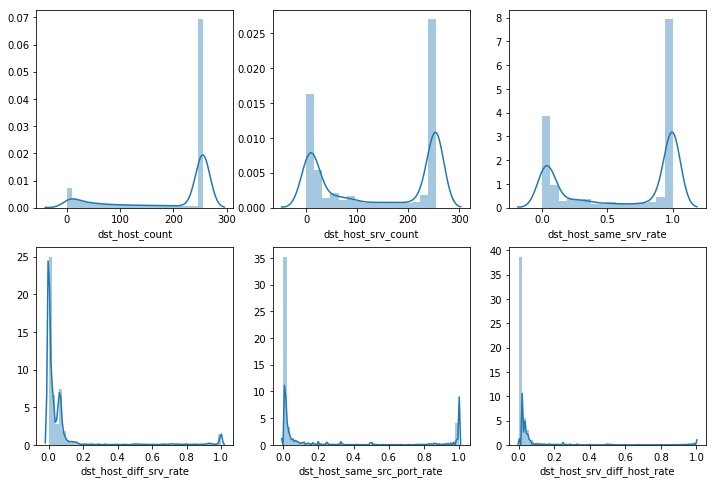

In [13]:
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
sns.distplot(kdd_test['dst_host_count'])

plt.subplot(2,3,2)
sns.distplot(kdd_test['dst_host_srv_count'])

plt.subplot(2,3,3)
sns.distplot(kdd_test['dst_host_same_srv_rate'])

plt.subplot(2,3,4)
sns.distplot(kdd_test['dst_host_diff_srv_rate'])


plt.subplot(2,3,5)
sns.distplot(kdd_test['dst_host_same_src_port_rate'])

plt.subplot(2,3,6)
sns.distplot(kdd_test['dst_host_srv_diff_host_rate'])

/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/mnt/disks/user/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "


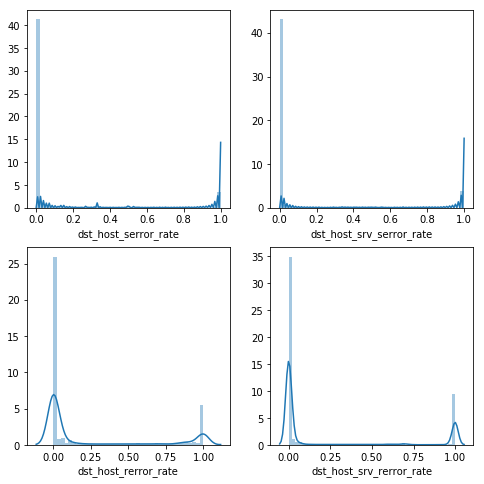

In [14]:
plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
sns.distplot(kdd_test['dst_host_serror_rate'])

plt.subplot(2,2,2)
sns.distplot(kdd_test['dst_host_srv_serror_rate'])

plt.subplot(2,2,3)
sns.distplot(kdd_test['dst_host_rerror_rate'])


plt.subplot(2,2,4)
sns.distplot(kdd_test['dst_host_srv_rerror_rate'])

In [70]:
kdd_test[host_attr].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
dst_host_count,22544.0,193.869411,94.035663,0.0,121.00,255.00,255.00,255.0
dst_host_srv_count,22544.0,140.750532,111.783972,0.0,15.00,168.00,255.00,255.0
dst_host_same_srv_rate,22544.0,0.608722,0.435688,0.0,0.07,0.92,1.00,1.0
dst_host_diff_srv_rate,22544.0,0.090540,0.220717,0.0,0.00,0.01,0.06,1.0
dst_host_same_src_port_rate,22544.0,0.132261,0.306268,0.0,0.00,0.00,0.03,1.0
dst_host_srv_diff_host_rate,22544.0,0.019638,0.085394,0.0,0.00,0.00,0.01,1.0
dst_host_serror_rate,22544.0,0.097814,0.273139,0.0,0.00,0.00,0.00,1.0
dst_host_srv_serror_rate,22544.0,0.099426,0.281866,0.0,0.00,0.00,0.00,1.0
dst_host_rerror_rate,22544.0,0.233385,0.387229,0.0,0.00,0.00,0.36,1.0
dst_host_srv_rerror_rate,22544.0,0.226683,0.400875,0.0,0.00,0.00,0.17,1.0


<Figure size 864x864 with 0 Axes>

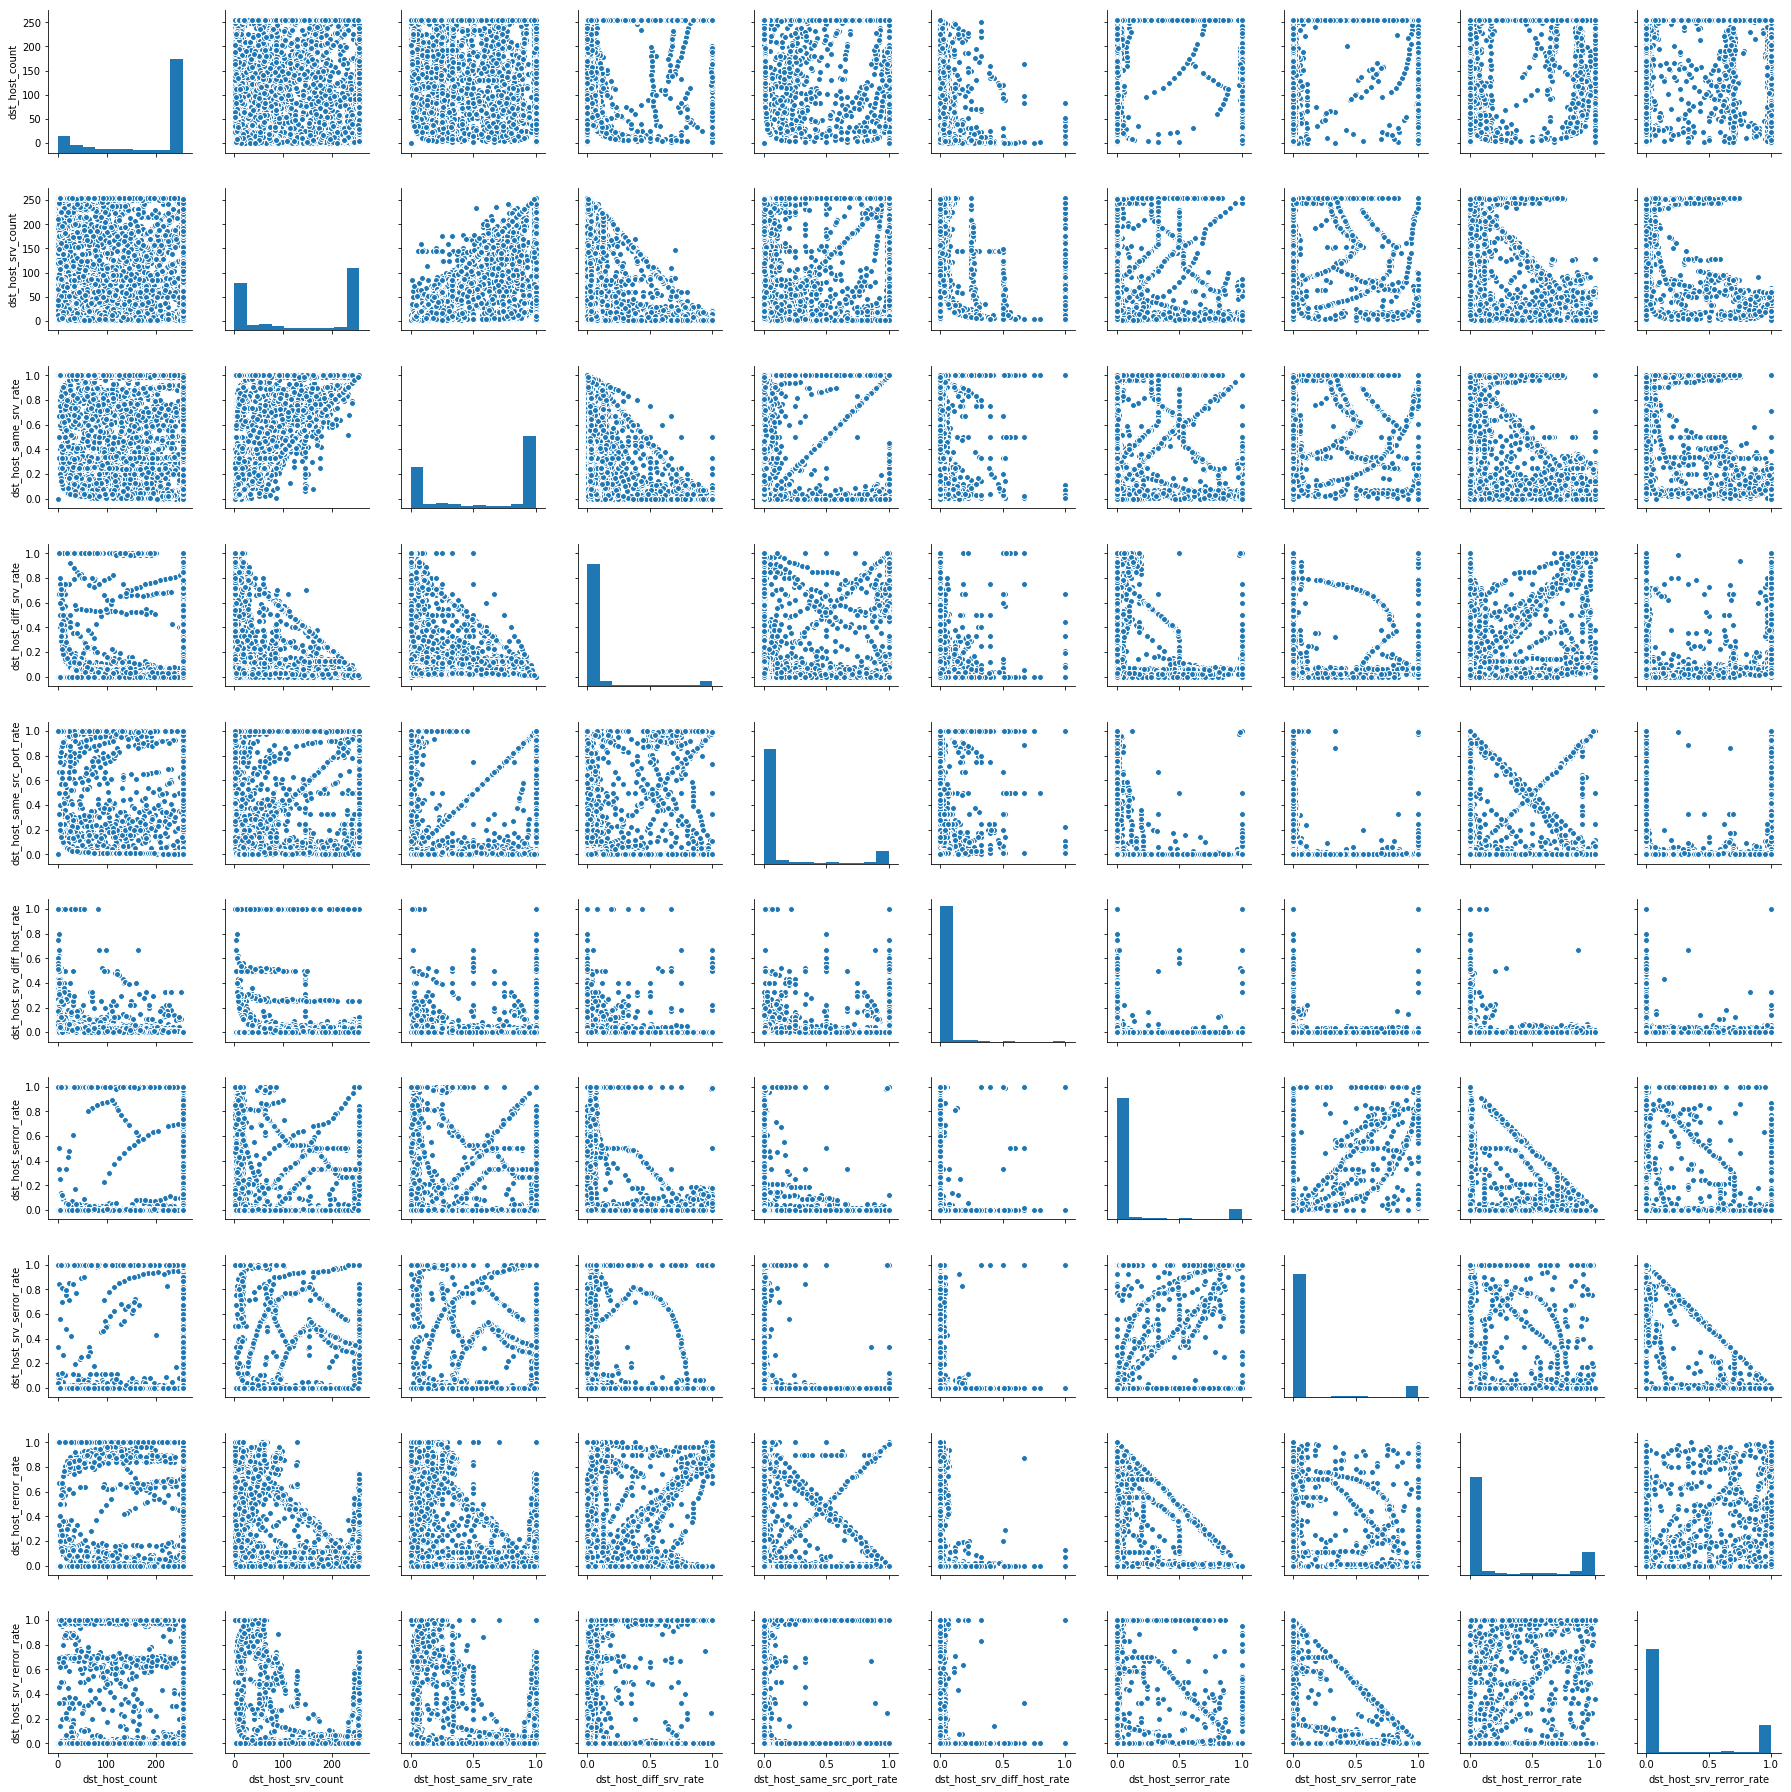

In [71]:
plt.figure(figsize = (12, 12))
sns.pairplot(kdd_test[host_attr])
plt.show()

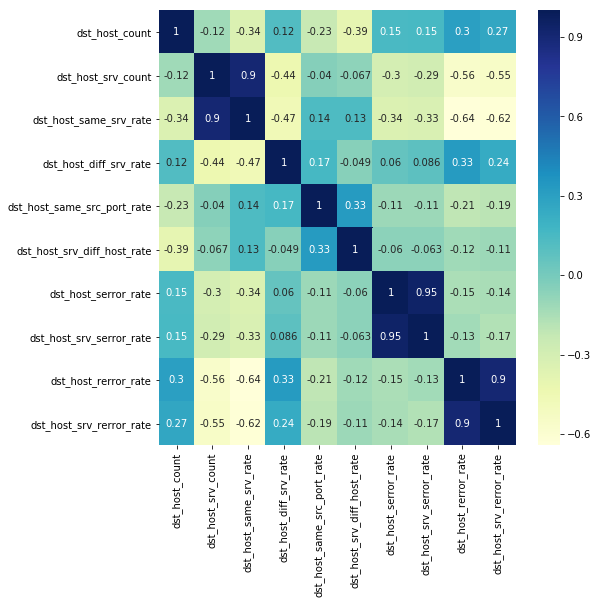

In [72]:
plt.figure(figsize = (8, 8))
sns.heatmap(kdd_test[host_attr].corr(), annot = True, cmap="YlGnBu")
plt.show()


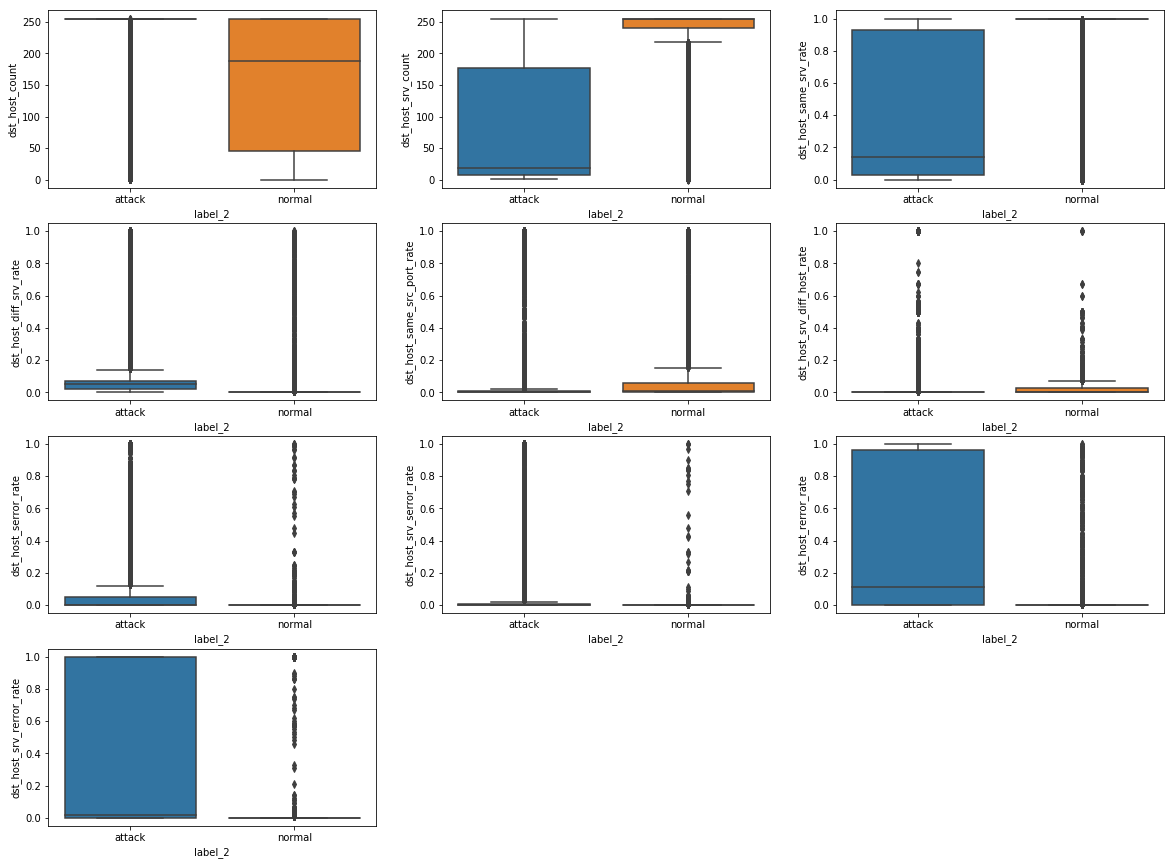

In [73]:
plt.figure(figsize=(20,15))
plt.subplot(4,3,1)
sns.boxplot(y='dst_host_count',data=kdd_test,x='label_2')
plt.subplot(4,3,2)
sns.boxplot(y='dst_host_srv_count',data=kdd_test,x='label_2')
plt.subplot(4,3,3)
sns.boxplot(y='dst_host_same_srv_rate',data=kdd_test,x='label_2')
plt.subplot(4,3,4)
sns.boxplot(y='dst_host_diff_srv_rate',data=kdd_test,x='label_2')
plt.subplot(4,3,5)
sns.boxplot(y='dst_host_same_src_port_rate',data=kdd_test,x='label_2')
plt.subplot(4,3,6)
sns.boxplot(y='dst_host_srv_diff_host_rate',data=kdd_test,x='label_2')
plt.subplot(4,3,7)
sns.boxplot(y='dst_host_serror_rate',data=kdd_test,x='label_2')
plt.subplot(4,3,8)
sns.boxplot(y='dst_host_srv_serror_rate',data=kdd_test,x='label_2')
plt.subplot(4,3,9)
sns.boxplot(y='dst_host_rerror_rate',data=kdd_test,x='label_2')
plt.subplot(4,3,10)
sns.boxplot(y='dst_host_srv_rerror_rate',data=kdd_test,x='label_2')


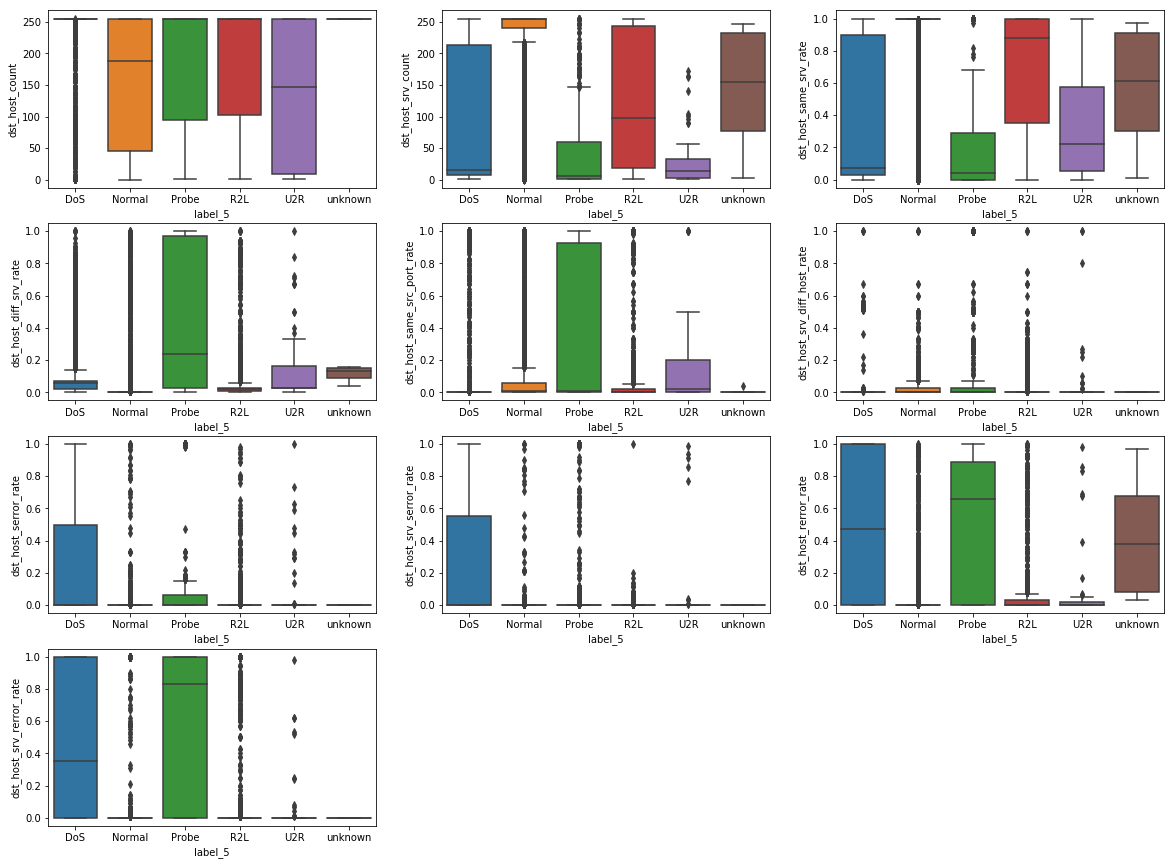

In [74]:
plt.figure(figsize=(20,15))
plt.subplot(4,3,1)
sns.boxplot(y='dst_host_count',data=kdd_test,x='label_5')
plt.subplot(4,3,2)
sns.boxplot(y='dst_host_srv_count',data=kdd_test,x='label_5')
plt.subplot(4,3,3)
sns.boxplot(y='dst_host_same_srv_rate',data=kdd_test,x='label_5')
plt.subplot(4,3,4)
sns.boxplot(y='dst_host_diff_srv_rate',data=kdd_test,x='label_5')
plt.subplot(4,3,5)
sns.boxplot(y='dst_host_same_src_port_rate',data=kdd_test,x='label_5')
plt.subplot(4,3,6)
sns.boxplot(y='dst_host_srv_diff_host_rate',data=kdd_test,x='label_5')
plt.subplot(4,3,7)
sns.boxplot(y='dst_host_serror_rate',data=kdd_test,x='label_5')
plt.subplot(4,3,8)
sns.boxplot(y='dst_host_srv_serror_rate',data=kdd_test,x='label_5')
plt.subplot(4,3,9)
sns.boxplot(y='dst_host_rerror_rate',data=kdd_test,x='label_5')
plt.subplot(4,3,10)
sns.boxplot(y='dst_host_srv_rerror_rate',data=kdd_test,x='label_5')


#### Top n correlation

In [75]:
def get_redundant_pairs(df):
    '''Get diagonal and lower triangular pairs of correlation matrix'''
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n=5):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]



In [76]:
kdd_test_num=kdd_test.select_dtypes([np.number])

In [77]:
print("Top Absolute Correlations")
print(get_top_abs_correlations(kdd_test_num,25))

Top Absolute Correlations
num_compromised         num_root                    0.995960
rerror_rate             srv_rerror_rate             0.975535
serror_rate             srv_serror_rate             0.966375
srv_rerror_rate         dst_host_srv_rerror_rate    0.947849
dst_host_serror_rate    dst_host_srv_serror_rate    0.945016
rerror_rate             dst_host_srv_rerror_rate    0.931025
srv_serror_rate         dst_host_srv_serror_rate    0.920969
dst_host_rerror_rate    dst_host_srv_rerror_rate    0.904745
dst_host_srv_count      dst_host_same_srv_rate      0.904360
serror_rate             dst_host_serror_rate        0.904100
                        dst_host_srv_serror_rate    0.900799
rerror_rate             dst_host_rerror_rate        0.877644
srv_serror_rate         dst_host_serror_rate        0.871620
srv_rerror_rate         dst_host_rerror_rate        0.860620
su_attempted            num_root                    0.819923
num_compromised         su_attempted                0.81774

In [78]:
kdd_test.shape

(22544, 45)

In [79]:
corr_drop_list=['num_root','srv_serror_rate','srv_rerror_rate','dst_host_srv_serror_rate','dst_host_srv_rerror_rate',
             'dst_host_serror_rate','dst_host_rerror_rate','dst_host_same_srv_rate','num_outbound_cmds','is_host_login']
kdd_test_df=kdd_test.drop(corr_drop_list,axis=1)
kdd_test_df.shape

(22544, 35)

In [80]:
kdd_test_num=kdd_test_df.select_dtypes([np.number])

In [81]:
print("Top Absolute Correlations")
print(get_top_abs_correlations(kdd_test_num,25))

Top Absolute Correlations
num_compromised     su_attempted                   0.817746
hot                 num_file_creations             0.726828
same_srv_rate       dst_host_srv_count             0.713543
rerror_rate         same_srv_rate                  0.638024
diff_srv_rate       dst_host_diff_srv_rate         0.605080
logged_in           dst_host_srv_count             0.581921
count               srv_count                      0.577955
                    same_srv_rate                  0.565443
logged_in           same_srv_rate                  0.529847
rerror_rate         dst_host_srv_count             0.507625
same_srv_rate       diff_srv_rate                  0.488495
logged_in           count                          0.488059
srv_count           dst_host_same_src_port_rate    0.457801
dst_host_srv_count  dst_host_diff_srv_rate         0.435102
dst_host_count      dst_host_srv_diff_host_rate    0.394961
count               rerror_rate                    0.377139
urgent        

In [82]:
categ_col=categ_basic + categ_content
categ_col

['protocol_type',
 'service',
 'flag',
 'wrong_fragment',
 'urgent',
 'last_flag',
 'hot',
 'num_failed_logins',
 'num_file_creations',
 'num_shells',
 'num_access_files']

In [83]:
import pickle

with open('categlist_test.txt', 'wb') as filehandle:
    # store the data as binary data stream
    pickle.dump(categ_col, filehandle)

In [84]:
#kdd_test_df.to_csv("kdd_test_eda.csv",index=False)